# Simulation output signal inference metrics

This notebook turns the detected gamma signal into first-pass inference metrics for three quantities:

1. **Diffusion fraction**: estimate the diffuse-source fraction from detector-profile shape.
2. **Material/signal amount**: estimate total detected signal in the measured area and convert it to a baseline-calibrated equivalent activity/material proxy.
3. **Secondary source**: test whether a localized secondary source is present and estimate where the residual hotspot appears on the detector.

The notebook reuses the repeated-run outputs and conventions from `Detector_performance_analysis_Rn222_repetition_comparison.ipynb` and `Detector_performance_analysis_Rn222_activity_normalized.ipynb`.

Important limitation: the current localized cases (`loc20`, `loc40`, `loc60`) change the **fraction** assigned to a localized secondary source, but both use the same secondary volume centered at `z = 50 cm`. That means the notebook can validate secondary-source detection and detector-hotspot localization for this location, but it cannot yet learn a general location-response model. More secondary locations are needed for that.


In [49]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', None)

figure_output_dir = Path('docs') / 'figures' / 'Simulation_output_signal_inference_metrics'
figure_output_dir.mkdir(parents=True, exist_ok=True)
metrics_output_dir = Path('outputs') / 'Simulation_output_signal_inference_metrics'
metrics_output_dir.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name):
    safe_name = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(name)).strip('_')
    path = figure_output_dir / f'{safe_name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'Saved figure: {path}')
    return path


## Configuration and case metadata

The labels below describe the simulation truth used only for calibration and validation. The feature extraction itself uses detector-entry photon columns (`volumeName`, `x_mm`, `y_mm`, `z_mm`, `time_s`, and counts), not the gamma-emission coordinates.


In [50]:
repetition_run_dir = Path('./rn222_repetition_runs/rn222_2mmfully_10reps_10k')
generated_files_log = repetition_run_dir / 'generated_files_log.tsv'
use_repetition_outputs = True

analysis_cases = {
    'baseline': {
        'label': 'No diffusion baseline',
        'path': Path('./PhotonDetector/build/2mm_2mm_10k_photon_boundaries.csv'),
        'diffusion_fraction': 0.0,
        'secondary_present': 0,
        'secondary_fraction': 0.0,
        'secondary_z_mm': np.nan,
    },
    'diff10': {
        'label': 'Source diffusion 10%',
        'path': Path('./PhotonDetector/build/2mm_2mm_10k_10diffRn222_photon_boundaries.csv'),
        'diffusion_fraction': 10.0,
        'secondary_present': 0,
        'secondary_fraction': 0.0,
        'secondary_z_mm': np.nan,
    },
    'diff50': {
        'label': 'Source diffusion 50%',
        'path': Path('./PhotonDetector/build/2mm_2mm_10k_50diffRn222_photon_boundaries.csv'),
        'diffusion_fraction': 50.0,
        'secondary_present': 0,
        'secondary_fraction': 0.0,
        'secondary_z_mm': np.nan,
    },
    'diff90': {
        'label': 'Source diffusion 90%',
        'path': Path('./PhotonDetector/build/2mm_2mm_10k_90diffRn222_photon_boundaries.csv'),
        'diffusion_fraction': 90.0,
        'secondary_present': 0,
        'secondary_fraction': 0.0,
        'secondary_z_mm': np.nan,
    },
    'loc20': {
        'label': 'Localised secondary 20%',
        'path': Path('./PhotonDetector/build/2mm_2mm_10k_20_Rn222_loc_photon_boundaries.csv'),
        'diffusion_fraction': np.nan,
        'secondary_present': 1,
        'secondary_fraction': 20.0,
        'secondary_z_mm': 500.0,
    },
    'loc40': {
        'label': 'Localised secondary 40%',
        'path': Path('./PhotonDetector/build/2mm_2mm_10k_40_Rn222_loc_photon_boundaries.csv'),
        'diffusion_fraction': np.nan,
        'secondary_present': 1,
        'secondary_fraction': 40.0,
        'secondary_z_mm': 500.0,
    },
    'loc60': {
        'label': 'Localised secondary 60%',
        'path': Path('./PhotonDetector/build/2mm_2mm_10k_60_Rn222_loc_photon_boundaries.csv'),
        'diffusion_fraction': np.nan,
        'secondary_present': 1,
        'secondary_fraction': 60.0,
        'secondary_z_mm': 500.0,
    },
}

case_labels = {key: value['label'] for key, value in analysis_cases.items()}
case_order = ['baseline', 'diff10', 'diff50', 'diff90', 'loc20', 'loc40', 'loc60']
diffusion_training_cases = ['baseline', 'diff10', 'diff50', 'diff90']
secondary_training_cases = case_order

panel_sets = {
    'PosY': ['physPhotonDetectorPosY'],
    'NegY': ['physPhotonDetectorNegY'],
    'PosX': ['physPhotonDetectorPosX'],
    'NegX': ['physPhotonDetectorNegX'],
    'Ysum': ['physPhotonDetectorPosY', 'physPhotonDetectorNegY'],
    'Xsum': ['physPhotonDetectorPosX', 'physPhotonDetectorNegX'],
    'All': ['physPhotonDetectorPosY', 'physPhotonDetectorNegY', 'physPhotonDetectorPosX', 'physPhotonDetectorNegX'],
}
all_detector_panels = panel_sets['All']

z_bins = np.linspace(-1500, 1500, 61)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
y_bins = np.linspace(-150, 150, 49)
y_centers = 0.5 * (y_bins[:-1] + y_bins[1:])
central_z_roi_mm = (-150, 150)
secondary_search_z_roi_mm = (250, 750)

def output_csv_from_stem(output_stem):
    return Path(f'{output_stem}_photon_boundaries.csv')


## Load repeated outputs

Each repetition is reduced to gamma entries into the four side detector panels. This matches the previous repeated-run notebooks and keeps the analysis based on detected photons.


In [51]:
def load_repetition(path, case_key, rep):
    usecols = [
        'eventID', 'particleName', 'boundary', 'volumeName',
        'x_mm', 'y_mm', 'z_mm', 'time_s', 'kineticEnergy_MeV'
    ]
    df = pd.read_csv(path, usecols=usecols)
    entries = df[
        (df['particleName'] == 'gamma')
        & (df['boundary'] == 'enter')
        & (df['volumeName'].isin(all_detector_panels))
    ].copy()
    return {
        'case': case_key,
        'rep': int(rep),
        'path': str(path),
        'entries': entries,
        'n_events': int(df['eventID'].nunique()),
    }


def load_repetition_cases():
    if use_repetition_outputs and generated_files_log.exists():
        log_df = pd.read_csv(generated_files_log, sep='	')
        reps_by_case = {key: [] for key in analysis_cases}
        skipped = []
        for row in log_df.itertuples(index=False):
            csv_path = output_csv_from_stem(row.output_stem)
            if row.case not in reps_by_case:
                continue
            if not csv_path.exists():
                skipped.append({'case': row.case, 'rep': row.rep, 'expected_csv': str(csv_path)})
                continue
            reps_by_case[row.case].append(load_repetition(csv_path, row.case, row.rep))
        return {case: reps for case, reps in reps_by_case.items() if reps}, pd.DataFrame(skipped)

    reps_by_case = {}
    for key, meta in analysis_cases.items():
        if meta['path'].exists():
            reps_by_case[key] = [load_repetition(meta['path'], key, 1)]
    return reps_by_case, pd.DataFrame()


def print_repetition_summary(cases, skipped_df):
    print('Loaded repetitions:')
    for key in case_order:
        if key not in cases:
            continue
        reps = [rep['rep'] for rep in cases[key]]
        n_entries = sum(len(rep['entries']) for rep in cases[key])
        print(f"  {key:8s}: {len(reps):2d} reps {reps}, {n_entries} detector entries")
    if not skipped_df.empty:
        print(f'Skipped missing outputs: {len(skipped_df)}')
        display(skipped_df.head(10))

cases, skipped_repetitions_df = load_repetition_cases()
print_repetition_summary(cases, skipped_repetitions_df)
if 'baseline' not in cases:
    raise RuntimeError('No baseline repetitions are available.')


Loaded repetitions:
  baseline: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 124660 detector entries
  diff10  : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 123556 detector entries
  diff50  : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 120368 detector entries
  diff90  : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 116158 detector entries
  loc20   : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 113307 detector entries
  loc40   : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 120263 detector entries
  loc60   : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 119213 detector entries
Skipped missing outputs: 280


,case,rep,expected_csv
0,baseline,11,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep11_photon_boundaries.csv
1,baseline,12,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep12_photon_boundaries.csv
2,baseline,13,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep13_photon_boundaries.csv
3,baseline,14,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep14_photon_boundaries.csv
4,baseline,15,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep15_photon_boundaries.csv
5,baseline,16,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep16_photon_boundaries.csv
6,baseline,17,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep17_photon_boundaries.csv
7,baseline,18,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep18_photon_boundaries.csv
8,baseline,19,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep19_photon_boundaries.csv
9,baseline,20,/Users/yw18581/work/theranostics/rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep20_photon_boundaries.csv


## Detector-signal feature extraction

The feature vector has three parts:

- Count/intensity features: total and panel-specific detections per generated decay.
- Shape features: normalized z-profile moments, quantile widths, and central/far ratios.
- Residual features: candidate profile minus the baseline mean profile, which provides hotspot and excess-signal summaries.

The same table is then used for diffusion regression, amount estimation, and secondary-source detection.


In [52]:
def select_entries(rep, panels, time_limit_s=None):
    selected = rep['entries'][rep['entries']['volumeName'].isin(panels)]
    if time_limit_s is not None:
        selected = selected[selected['time_s'].notna() & (selected['time_s'] <= time_limit_s)]
    return selected


def hist_counts(rep, panels, bins=z_bins, coord='z_mm', time_limit_s=None):
    selected = select_entries(rep, panels, time_limit_s=time_limit_s)
    return np.histogram(selected[coord], bins=bins)[0].astype(float)


def baseline_mean_profiles(cases, bins=z_bins):
    profiles = {}
    for view_name, panels in panel_sets.items():
        counts = np.vstack([hist_counts(rep, panels, bins=bins) / rep['n_events'] for rep in cases['baseline']])
        profiles[view_name] = counts.mean(axis=0)
    return profiles

baseline_profiles = baseline_mean_profiles(cases)


def weighted_mean_std(values, weights):
    weights = np.asarray(weights, dtype=float)
    values = np.asarray(values, dtype=float)
    total = weights.sum()
    if total <= 0:
        return np.nan, np.nan
    mean = np.sum(values * weights) / total
    var = np.sum(weights * (values - mean) ** 2) / total
    return mean, np.sqrt(max(var, 0.0))


def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if weights.sum() <= 0:
        return [np.nan for _ in quantiles]
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cdf = np.cumsum(weights) / weights.sum()
    return np.interp(quantiles, cdf, values)


def positive_weighted_position(centers, residual):
    positive = np.clip(np.asarray(residual, dtype=float), 0, None)
    total = positive.sum()
    if total <= 0:
        return np.nan
    return float(np.sum(np.asarray(centers) * positive) / total)


def extract_features_for_rep(rep, baseline_profiles):
    row = {
        'case': rep['case'],
        'rep': rep['rep'],
        'label': case_labels[rep['case']],
        'n_events': rep['n_events'],
        'diffusion_fraction_true': analysis_cases[rep['case']]['diffusion_fraction'],
        'secondary_present_true': analysis_cases[rep['case']]['secondary_present'],
        'secondary_fraction_true': analysis_cases[rep['case']]['secondary_fraction'],
        'secondary_z_mm_true': analysis_cases[rep['case']]['secondary_z_mm'],
    }

    all_rate = len(select_entries(rep, panel_sets['All'])) / rep['n_events']
    row['detected_rate_all_per_event'] = all_rate

    for view_name, panels in panel_sets.items():
        counts = hist_counts(rep, panels)
        rate_profile = counts / rep['n_events']
        total_counts = counts.sum()
        total_rate = total_counts / rep['n_events']
        normalized_shape = counts / total_counts if total_counts > 0 else np.zeros_like(counts)

        mean_z, std_z = weighted_mean_std(z_centers, counts)
        q10, q50, q90 = weighted_quantile(z_centers, counts, [0.10, 0.50, 0.90])
        central_mask = (z_centers >= central_z_roi_mm[0]) & (z_centers <= central_z_roi_mm[1])
        secondary_mask = (z_centers >= secondary_search_z_roi_mm[0]) & (z_centers <= secondary_search_z_roi_mm[1])
        far_mask = ~central_mask
        residual = rate_profile - baseline_profiles[view_name]
        positive_residual = np.clip(residual, 0, None)
        positive_residual_total = positive_residual.sum()

        prefix = f'{view_name}_'
        row[prefix + 'rate_per_event'] = total_rate
        row[prefix + 'fraction_of_all'] = total_rate / all_rate if all_rate > 0 else np.nan
        row[prefix + 'z_mean_mm'] = mean_z
        row[prefix + 'z_std_mm'] = std_z
        row[prefix + 'z_q10_mm'] = q10
        row[prefix + 'z_median_mm'] = q50
        row[prefix + 'z_q90_mm'] = q90
        row[prefix + 'z_q80_width_mm'] = q90 - q10 if np.isfinite(q90) and np.isfinite(q10) else np.nan
        row[prefix + 'central_rate_per_event'] = counts[central_mask].sum() / rep['n_events']
        row[prefix + 'far_rate_per_event'] = counts[far_mask].sum() / rep['n_events']
        row[prefix + 'central_fraction'] = counts[central_mask].sum() / total_counts if total_counts > 0 else np.nan
        row[prefix + 'secondary_roi_rate_per_event'] = counts[secondary_mask].sum() / rep['n_events']
        row[prefix + 'residual_l1_per_event'] = np.abs(residual).sum()
        row[prefix + 'positive_residual_per_event'] = positive_residual_total
        row[prefix + 'positive_residual_centroid_z_mm'] = positive_weighted_position(z_centers, residual)
        row[prefix + 'positive_residual_peak_z_mm'] = z_centers[np.argmax(residual)] if len(residual) else np.nan
        row[prefix + 'positive_residual_peak_per_event'] = np.max(residual) if len(residual) else np.nan

        for i, value in enumerate(normalized_shape):
            row[f'{prefix}shape_bin_{i:02d}'] = value
        for i, value in enumerate(residual):
            row[f'{prefix}residual_bin_{i:02d}'] = value

    pos_y = row['PosY_rate_per_event']
    neg_y = row['NegY_rate_per_event']
    pos_x = row['PosX_rate_per_event']
    neg_x = row['NegX_rate_per_event']
    row['Y_panel_asymmetry'] = (pos_y - neg_y) / (pos_y + neg_y) if (pos_y + neg_y) > 0 else np.nan
    row['X_panel_asymmetry'] = (pos_x - neg_x) / (pos_x + neg_x) if (pos_x + neg_x) > 0 else np.nan
    row['Y_to_X_rate_ratio'] = row['Ysum_rate_per_event'] / row['Xsum_rate_per_event'] if row['Xsum_rate_per_event'] > 0 else np.nan
    return row

feature_rows = []
for case_key in case_order:
    for rep in cases.get(case_key, []):
        feature_rows.append(extract_features_for_rep(rep, baseline_profiles))

features_df = pd.DataFrame(feature_rows)
features_df.to_csv(metrics_output_dir / 'detector_signal_features.csv', index=False)
print(f'Feature table: {features_df.shape[0]} repetitions x {features_df.shape[1]} columns')
display(features_df[['case', 'rep', 'diffusion_fraction_true', 'secondary_present_true', 'secondary_fraction_true', 'detected_rate_all_per_event', 'All_z_std_mm', 'All_positive_residual_peak_z_mm']].head(12))


Feature table: 70 repetitions x 971 columns


,case,rep,diffusion_fraction_true,secondary_present_true,secondary_fraction_true,detected_rate_all_per_event,All_z_std_mm,All_positive_residual_peak_z_mm
0,baseline,1,0.0,0,0.0,1.483451,234.622978,-25.0
1,baseline,2,0.0,0,0.0,1.489755,233.346795,-25.0
2,baseline,3,0.0,0,0.0,1.476882,239.125344,-175.0
3,baseline,4,0.0,0,0.0,1.495469,236.991048,-225.0
4,baseline,5,0.0,0,0.0,1.491862,235.183575,75.0
5,baseline,6,0.0,0,0.0,1.490881,236.007557,-75.0
6,baseline,7,0.0,0,0.0,1.481032,241.574433,-425.0
7,baseline,8,0.0,0,0.0,1.488355,235.616304,25.0
8,baseline,9,0.0,0,0.0,1.496073,234.966002,125.0
9,baseline,10,0.0,0,0.0,1.491293,236.386077,225.0


## 1. Diffusion fraction from signal shape

This model is trained only on baseline and diffuse cases (`baseline`, `diff10`, `diff50`, `diff90`). It deliberately excludes `loc20`, `loc40`, and `loc60`, because those are a different physical hypothesis: a compact secondary source rather than broad diffusion.

The regression uses normalized profile-shape and asymmetry features so the result is less tied to total source amount.


LOO MAE: 1.2 percentage points
LOO R^2: 0.998


,case,true_diffusion_fraction,predicted_mean,predicted_sd,predicted_min,predicted_max,n
0,baseline,0.0,0.644970,1.252986,0.000000,3.394600,10
1,diff10,10.0,11.132270,1.559758,8.107005,14.159685,10
2,diff50,50.0,48.783689,0.941078,47.102337,50.243180,10
3,diff90,90.0,90.042575,1.903251,86.784662,92.896502,10


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/diffusion_fraction_cv_prediction.png


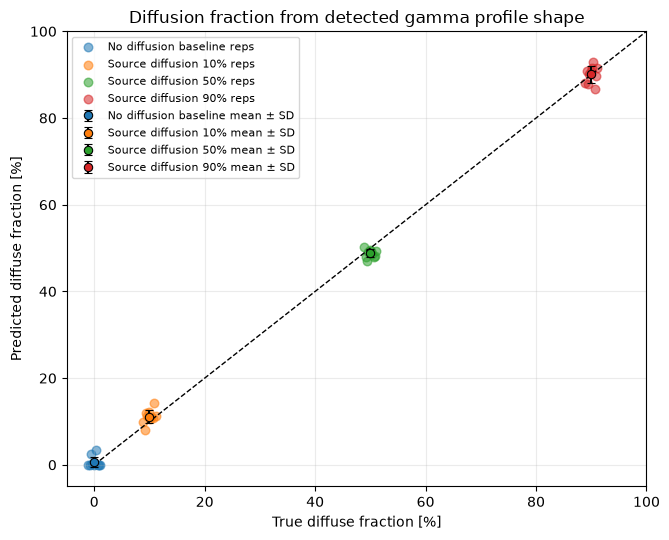

In [53]:
def columns_matching(df, prefixes=(), contains=()):
    cols = []
    for col in df.columns:
        if prefixes and not any(col.startswith(prefix) for prefix in prefixes):
            continue
        if contains and not any(token in col for token in contains):
            continue
        cols.append(col)
    return cols

shape_feature_cols = []
shape_feature_cols += columns_matching(features_df, prefixes=('PosY_', 'NegY_', 'Ysum_', 'Xsum_', 'All_'), contains=('shape_bin_',))
shape_feature_cols += [
    col for col in features_df.columns
    if any(col.endswith(suffix) for suffix in [
        'z_std_mm', 'z_q80_width_mm', 'central_fraction', 'positive_residual_centroid_z_mm',
        'positive_residual_peak_z_mm', 'residual_l1_per_event'
    ])
]
shape_feature_cols += ['Y_panel_asymmetry', 'X_panel_asymmetry', 'Y_to_X_rate_ratio']
shape_feature_cols = sorted(set(shape_feature_cols))

train_diff = features_df[features_df['case'].isin(diffusion_training_cases)].copy()
X_diff = train_diff[shape_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
y_diff = train_diff['diffusion_fraction_true'].to_numpy(dtype=float)

loo = LeaveOneOut()
diff_pred = np.zeros(len(train_diff))
for train_idx, test_idx in loo.split(X_diff):
    model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-4, 4, 25)))
    model.fit(X_diff.iloc[train_idx], y_diff[train_idx])
    diff_pred[test_idx] = model.predict(X_diff.iloc[test_idx])

diff_model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-4, 4, 25)))
diff_model.fit(X_diff, y_diff)
train_diff['diffusion_fraction_pred_cv'] = np.clip(diff_pred, 0, 100)

diffusion_summary = train_diff.groupby('case', sort=False).agg(
    true_diffusion_fraction=('diffusion_fraction_true', 'first'),
    predicted_mean=('diffusion_fraction_pred_cv', 'mean'),
    predicted_sd=('diffusion_fraction_pred_cv', 'std'),
    predicted_min=('diffusion_fraction_pred_cv', 'min'),
    predicted_max=('diffusion_fraction_pred_cv', 'max'),
    n=('diffusion_fraction_pred_cv', 'size'),
).reset_index()

print(f"LOO MAE: {mean_absolute_error(y_diff, train_diff['diffusion_fraction_pred_cv']):.1f} percentage points")
print(f"LOO R^2: {r2_score(y_diff, train_diff['diffusion_fraction_pred_cv']):.3f}")
display(diffusion_summary)

diffusion_summary.to_csv(metrics_output_dir / 'diffusion_fraction_cv_summary.csv', index=False)
train_diff[['case', 'rep', 'diffusion_fraction_true', 'diffusion_fraction_pred_cv']].to_csv(metrics_output_dir / 'diffusion_fraction_cv_predictions.csv', index=False)

fig, ax = plt.subplots(figsize=(6.8, 5.5))
case_colors = dict(zip(diffusion_training_cases, plt.cm.tab10(np.arange(len(diffusion_training_cases)))))
for case_key, group in train_diff.groupby('case', sort=False):
    color = case_colors[case_key]
    x_true = group['diffusion_fraction_true'].iloc[0]
    # Small deterministic horizontal jitter keeps repeated points visible without changing their meaning.
    jitter = np.linspace(-1.1, 1.1, len(group)) if len(group) > 1 else np.array([0.0])
    ax.scatter(
        x_true + jitter,
        group['diffusion_fraction_pred_cv'],
        s=38,
        alpha=0.55,
        color=color,
        label=f'{case_labels[case_key]} reps',
    )
    ax.errorbar(
        x_true,
        group['diffusion_fraction_pred_cv'].mean(),
        yerr=group['diffusion_fraction_pred_cv'].std(),
        fmt='o',
        ms=6,
        color=color,
        mec='black',
        mew=0.8,
        capsize=3,
        ecolor='k',
        label=f'{case_labels[case_key]} mean ± SD',
    )
ax.plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1)
ax.set_xlim(-5, 100)
ax.set_ylim(-5, 100)
ax.set_xlabel('True diffuse fraction [%]')
ax.set_ylabel('Predicted diffuse fraction [%]')
ax.set_title('Diffusion fraction from detected gamma profile shape')
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'diffusion_fraction_cv_prediction')
plt.show()


## 1b. Hand-defined diffusion-sensitive metrics

This cell implements an interpretable alternative to the Ridge model. It uses three scalar observables that should vary monotonically with broad diffusion: `Y_panel_asymmetry`, `Ysum_z_q80_width_mm`, and `PosY_central_fraction`. Each observable is calibrated against the known diffuse simulation cases (`0`, `10`, `50`, `90%`) with a monotone-preserving PCHIP interpolation, then applied repetition-by-repetition.

These scalar estimates are only meaningful after excluding compact secondary-source cases, because a localized secondary source can also broaden or deplete the central profile.


Calibration points used by the hand-defined scalar metrics:


,case,true_diffusion_fraction,Ay_asymmetry,Ysum_q80_width,PosY_central_fraction
0,baseline,0.0,0.611007,563.949406,0.568645
1,diff10,10.0,0.563544,623.936949,0.545151
2,diff50,50.0,0.346131,884.470393,0.454637
3,diff90,90.0,0.074738,1107.246581,0.285952


,case,true_diffusion_fraction,Ay_asymmetry_mean,Ysum_q80_width_mean,PosY_central_fraction_mean,scalar_mean,scalar_mean_sd,scalar_spread_mean,n
0,baseline,0.0,0.837035,0.404311,0.966090,0.735812,0.827804,0.650992,10
1,diff10,10.0,9.979442,9.988417,10.045220,10.004360,2.014826,1.134044,10
2,diff50,50.0,49.974382,50.013260,49.915579,49.967740,1.666095,1.668945,10
3,diff90,90.0,89.992922,90.002108,89.954309,89.983113,0.793049,0.557946,10
4,loc20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
5,loc40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
6,loc60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10


Scalar mean MAE: 1.04 percentage points
Scalar mean R^2: 0.998
Saved figure: docs/figures/Simulation_output_signal_inference_metrics/diffusion_scalar_metric_calibration.png


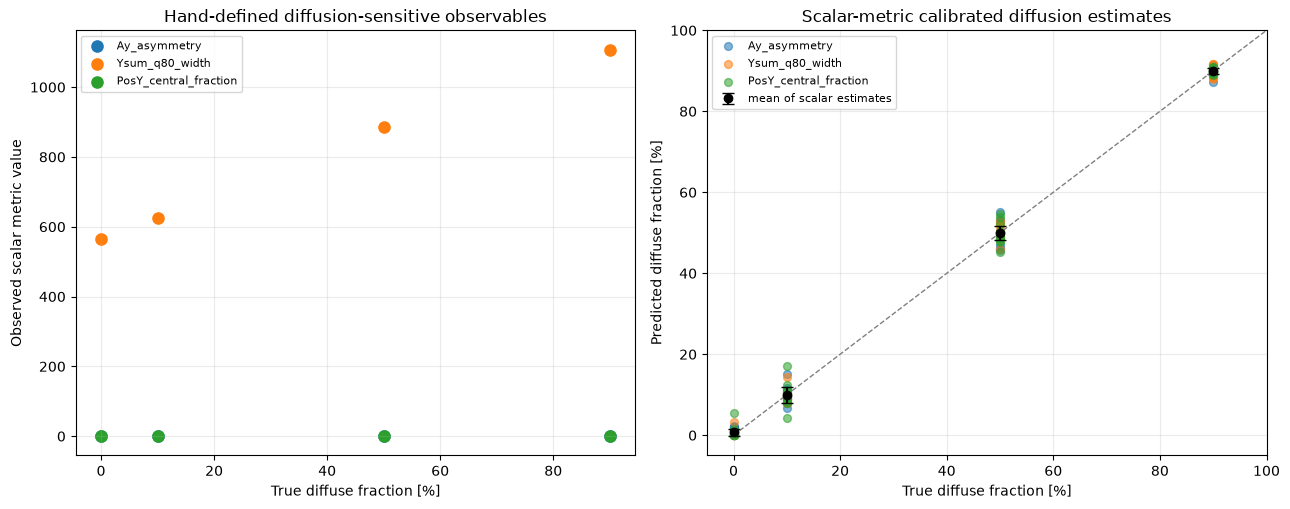

In [54]:
from scipy.interpolate import PchipInterpolator

# Hand-defined scalar diffusion metrics. Direction documents the expected trend
# with increasing diffusion and is used only for readability/checking.
scalar_diffusion_metrics = {
    'Ay_asymmetry': {
        'column': 'Y_panel_asymmetry',
        'description': '(PosY - NegY) / (PosY + NegY); decreases as source leaves the +Y applicator side',
        'direction': 'decreases',
    },
    'Ysum_q80_width': {
        'column': 'Ysum_z_q80_width_mm',
        'description': 'Ysum z10-z90 inter-quantile width; increases as longitudinal signal broadens',
        'direction': 'increases',
    },
    'PosY_central_fraction': {
        'column': 'PosY_central_fraction',
        'description': 'fraction of +Y-panel hits with |z| <= 150 mm; decreases as signal leaves applicator footprint',
        'direction': 'decreases',
    },
}

scalar_calibration_points = (
    features_df[features_df['case'].isin(diffusion_training_cases)]
    .groupby('case', sort=False)
    .agg(
        true_diffusion_fraction=('diffusion_fraction_true', 'first'),
        Ay_asymmetry=('Y_panel_asymmetry', 'mean'),
        Ysum_q80_width=('Ysum_z_q80_width_mm', 'mean'),
        PosY_central_fraction=('PosY_central_fraction', 'mean'),
    )
    .reindex(diffusion_training_cases)
    .reset_index()
)
print('Calibration points used by the hand-defined scalar metrics:')
display(scalar_calibration_points)

# Fit one interpolation curve per scalar metric: observed metric -> diffusion percent.
# PCHIP preserves the shape of the calibration curve and avoids polynomial ringing.
scalar_diffusion_fits = {}
for metric_name in scalar_diffusion_metrics:
    x = scalar_calibration_points[metric_name].to_numpy(dtype=float)
    y = scalar_calibration_points['true_diffusion_fraction'].to_numpy(dtype=float)
    order = np.argsort(x)
    scalar_diffusion_fits[metric_name] = PchipInterpolator(x[order], y[order], extrapolate=True)


def predict_scalar_diffusion(row):
    preds = {}
    for metric_name, meta in scalar_diffusion_metrics.items():
        value = float(row[meta['column']])
        preds[metric_name] = float(np.clip(scalar_diffusion_fits[metric_name](value), 0, 100))
    preds['scalar_mean'] = float(np.mean(list(preds.values())))
    preds['scalar_spread'] = float(np.std(list(preds.values()), ddof=0))
    return preds

scalar_prediction_rows = []
for _, row in features_df.iterrows():
    preds = predict_scalar_diffusion(row)
    preds.update({
        'case': row['case'],
        'rep': row['rep'],
        'label': row['label'],
        'true_diffusion_fraction': row['diffusion_fraction_true'],
        'secondary_present_true': row['secondary_present_true'],
    })
    scalar_prediction_rows.append(preds)

scalar_diffusion_predictions_df = pd.DataFrame(scalar_prediction_rows)
# The scalar diffusion estimate is reported only for the diffuse/no-secondary calibration family.
for col in ['Ay_asymmetry', 'Ysum_q80_width', 'PosY_central_fraction', 'scalar_mean', 'scalar_spread']:
    scalar_diffusion_predictions_df.loc[
        ~scalar_diffusion_predictions_df['case'].isin(diffusion_training_cases), col
    ] = np.nan

scalar_diffusion_summary_df = (
    scalar_diffusion_predictions_df
    .groupby('case', sort=False)
    .agg(
        true_diffusion_fraction=('true_diffusion_fraction', 'first'),
        Ay_asymmetry_mean=('Ay_asymmetry', 'mean'),
        Ysum_q80_width_mean=('Ysum_q80_width', 'mean'),
        PosY_central_fraction_mean=('PosY_central_fraction', 'mean'),
        scalar_mean=('scalar_mean', 'mean'),
        scalar_mean_sd=('scalar_mean', 'std'),
        scalar_spread_mean=('scalar_spread', 'mean'),
        n=('rep', 'size'),
    )
    .reindex(case_order)
    .reset_index()
)

display(scalar_diffusion_summary_df)
scalar_diffusion_predictions_df.to_csv(metrics_output_dir / 'diffusion_scalar_metric_predictions.csv', index=False)
scalar_diffusion_summary_df.to_csv(metrics_output_dir / 'diffusion_scalar_metric_summary.csv', index=False)

calib_diff = scalar_diffusion_predictions_df[
    scalar_diffusion_predictions_df['case'].isin(diffusion_training_cases)
].copy()
print(
    'Scalar mean MAE: '
    f"{mean_absolute_error(calib_diff['true_diffusion_fraction'], calib_diff['scalar_mean']):.2f} percentage points"
)
print(
    'Scalar mean R^2: '
    f"{r2_score(calib_diff['true_diffusion_fraction'], calib_diff['scalar_mean']):.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
for metric_name, meta in scalar_diffusion_metrics.items():
    ax.scatter(
        scalar_calibration_points['true_diffusion_fraction'],
        scalar_calibration_points[metric_name],
        s=65,
        label=metric_name,
    )
ax.set_xlabel('True diffuse fraction [%]')
ax.set_ylabel('Observed scalar metric value')
ax.set_title('Hand-defined diffusion-sensitive observables')
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

ax = axes[1]
for metric_name in scalar_diffusion_metrics:
    ax.scatter(
        calib_diff['true_diffusion_fraction'],
        calib_diff[metric_name],
        s=32,
        alpha=0.55,
        label=metric_name,
    )
ax.errorbar(
    scalar_diffusion_summary_df['true_diffusion_fraction'],
    scalar_diffusion_summary_df['scalar_mean'],
    yerr=scalar_diffusion_summary_df['scalar_mean_sd'],
    fmt='ko',
    capsize=4,
    label='mean of scalar estimates',
)
ax.plot([0, 100], [0, 100], color='grey', linestyle='--', linewidth=1)
ax.set_xlim(-5, 100)
ax.set_ylim(-5, 100)
ax.set_xlabel('True diffuse fraction [%]')
ax.set_ylabel('Predicted diffuse fraction [%]')
ax.set_title('Scalar-metric calibrated diffusion estimates')
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'diffusion_scalar_metric_calibration')
plt.show()


## 2. Material / signal amount in the measured area

The most direct observable for material amount is the detected gamma rate in the measured detector area. Here it is reported three ways:

- `detected_rate_all_per_event`: raw detector entries per generated source decay.
- `relative_total_signal_vs_baseline`: total measured signal relative to the baseline case.
- `relative_central_signal_vs_baseline`: signal in the central z ROI relative to baseline, a proxy for material remaining near the original applicator region.

For real measurements, replace `n_events` with acquisition live time and use an activity calibration source to convert rates into activity or surface loading. The baseline-equivalent activity calculation below is a calibration placeholder, not a detector-efficiency proof.


,case,label,total_rate_mean,total_rate_sd,relative_total_signal_mean,relative_total_signal_sd,central_signal_mean,central_signal_sd,baseline_equivalent_activity_uCi_mean,baseline_equivalent_activity_uCi_sd,z_width_mm_mean
0,baseline,No diffusion baseline,1.488505,0.006223,1.000000,0.004181,1.000000,0.010493,3.000000,0.012542,574.674366
1,diff10,Source diffusion 10%,1.487312,0.008229,0.999198,0.005528,0.939823,0.008126,2.997594,0.016584,638.955194
2,diff50,Source diffusion 50%,1.491542,0.012783,1.002040,0.008588,0.721314,0.012491,3.006119,0.025764,910.621859
3,diff90,Source diffusion 90%,1.476668,0.004144,0.992048,0.002784,0.467649,0.008682,2.976143,0.008352,1116.088433
4,loc20,Localised secondary 20%,1.501906,0.012363,1.009003,0.008306,0.846326,0.011410,3.027009,0.024917,763.495420
5,loc40,Localised secondary 40%,1.499289,0.009599,1.007245,0.006449,0.668767,0.012569,3.021735,0.019347,815.173549
6,loc60,Localised secondary 60%,1.507104,0.007550,1.012495,0.005072,0.503615,0.008705,3.037485,0.015216,802.481304


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/material_signal_amount_summary.png


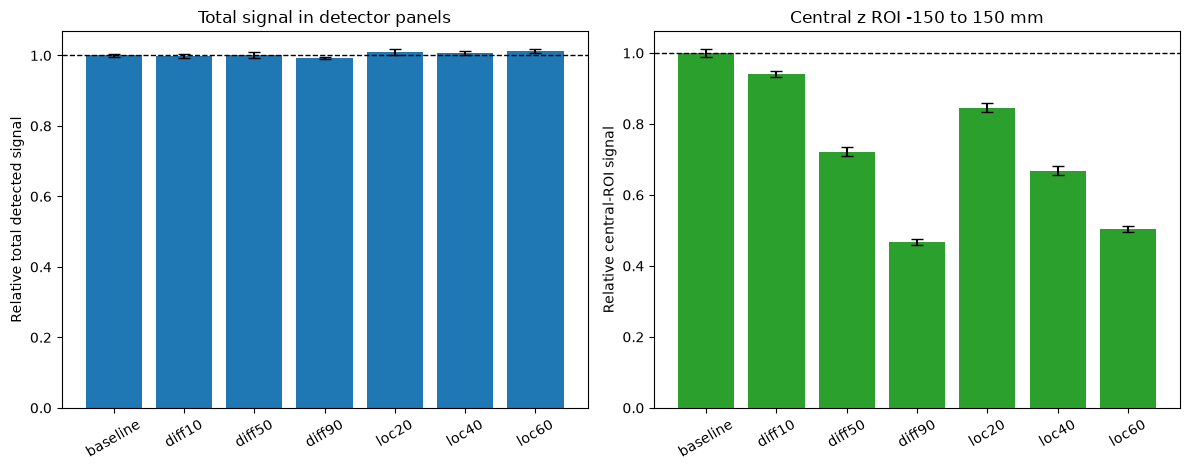

Saved figure: docs/figures/Simulation_output_signal_inference_metrics/material_signal_activity_estimates.png


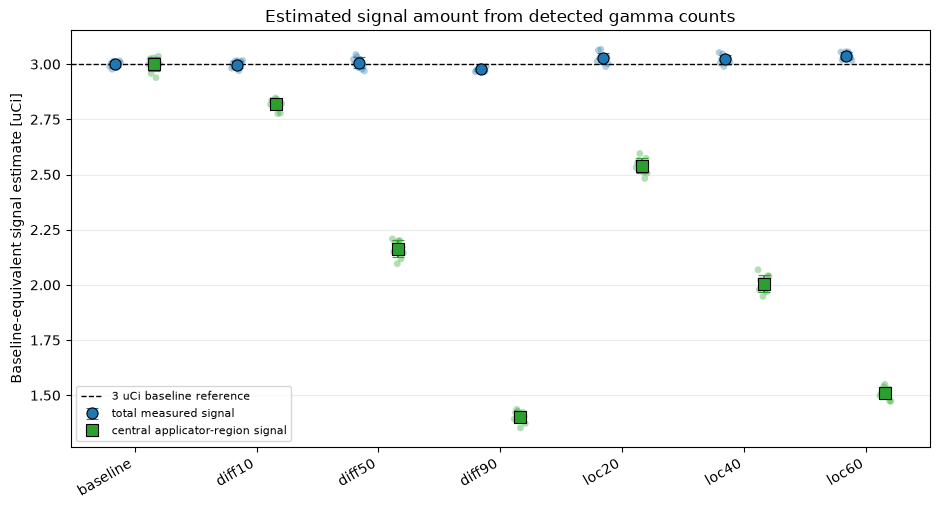

Saved figure: docs/figures/Simulation_output_signal_inference_metrics/material_signal_central_roi_profiles.png


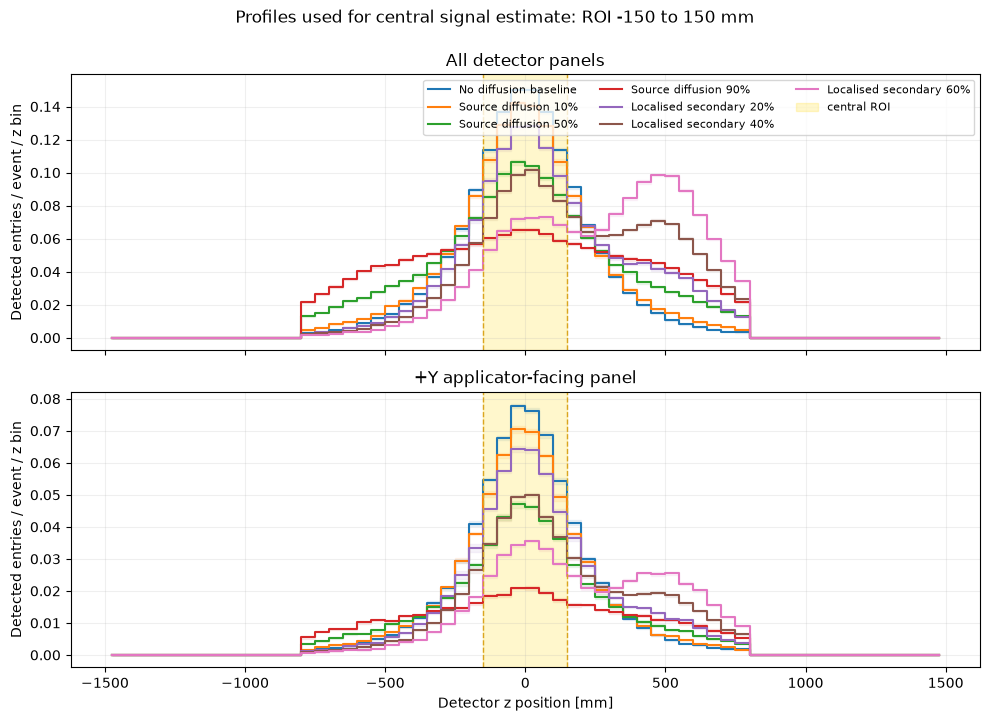

,case,label,secondary_fraction_true,applicator_zhat_mean_mm,applicator_zhat_sd_mm,applicator_z_width_mean_mm,applicator_centroid_stat_se_mean_mm,relative_applicator_signal_mean,relative_applicator_signal_sd,applicator_equivalent_activity_uCi_mean,applicator_equivalent_activity_uCi_sd
0,baseline,No diffusion baseline,0.0,-0.086648,1.267562,80.144806,1.385901,1.000000,0.012551,3.000000,0.037654
1,diff10,Source diffusion 10%,0.0,-0.452437,1.862040,80.166831,1.457371,0.912240,0.013969,2.736720,0.041906
2,diff50,Source diffusion 50%,0.0,0.510357,2.176689,81.059096,1.810266,0.622282,0.014578,1.866847,0.043735
3,diff90,Source diffusion 90%,0.0,-0.857726,3.357876,82.838213,2.748478,0.289286,0.008925,0.867859,0.026776
4,loc20,Localised secondary 20%,20.0,-0.455438,1.277314,80.033577,1.717594,0.832688,0.008989,2.498065,0.026968
5,loc40,Localised secondary 40%,40.0,1.202851,1.300516,80.455781,1.772704,0.643364,0.020189,1.930091,0.060567
6,loc60,Localised secondary 60%,60.0,3.543806,2.538303,81.098303,2.106464,0.469352,0.010431,1.408055,0.031294


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/applicator_component_signal_and_position.png


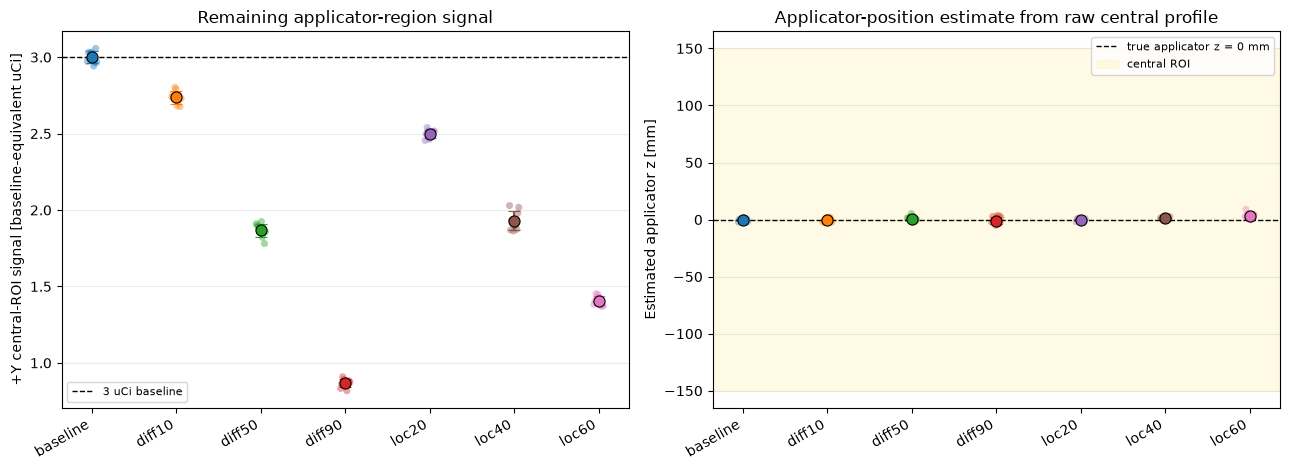

In [55]:
reference_activity_uCi = 3.0
baseline_total_rate = features_df.loc[features_df['case'] == 'baseline', 'detected_rate_all_per_event'].mean()
baseline_central_rate = features_df.loc[features_df['case'] == 'baseline', 'All_central_rate_per_event'].mean()

amount_df = features_df[[
    'case', 'rep', 'label', 'detected_rate_all_per_event', 'All_central_rate_per_event',
    'Ysum_rate_per_event', 'Xsum_rate_per_event', 'All_z_std_mm', 'All_z_q80_width_mm'
]].copy()
amount_df['relative_total_signal_vs_baseline'] = amount_df['detected_rate_all_per_event'] / baseline_total_rate
amount_df['relative_central_signal_vs_baseline'] = amount_df['All_central_rate_per_event'] / baseline_central_rate
amount_df['baseline_equivalent_activity_uCi'] = amount_df['relative_total_signal_vs_baseline'] * reference_activity_uCi

amount_summary = amount_df.groupby('case', sort=False).agg(
    label=('label', 'first'),
    total_rate_mean=('detected_rate_all_per_event', 'mean'),
    total_rate_sd=('detected_rate_all_per_event', 'std'),
    relative_total_signal_mean=('relative_total_signal_vs_baseline', 'mean'),
    relative_total_signal_sd=('relative_total_signal_vs_baseline', 'std'),
    central_signal_mean=('relative_central_signal_vs_baseline', 'mean'),
    central_signal_sd=('relative_central_signal_vs_baseline', 'std'),
    baseline_equivalent_activity_uCi_mean=('baseline_equivalent_activity_uCi', 'mean'),
    baseline_equivalent_activity_uCi_sd=('baseline_equivalent_activity_uCi', 'std'),
    z_width_mm_mean=('All_z_q80_width_mm', 'mean'),
).reset_index()

display(amount_summary)
amount_df.to_csv(metrics_output_dir / 'material_signal_amount_by_repetition.csv', index=False)
amount_summary.to_csv(metrics_output_dir / 'material_signal_amount_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
plot_order = [key for key in case_order if key in amount_summary['case'].values]
plot_summary = amount_summary.set_index('case').loc[plot_order].reset_index()

axes[0].bar(plot_summary['case'], plot_summary['relative_total_signal_mean'], yerr=plot_summary['relative_total_signal_sd'], capsize=4)
axes[0].axhline(1, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel('Relative total detected signal')
axes[0].set_title('Total signal in detector panels')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(plot_summary['case'], plot_summary['central_signal_mean'], yerr=plot_summary['central_signal_sd'], capsize=4, color='tab:green')
axes[1].axhline(1, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Relative central-ROI signal')
axes[1].set_title(f'Central z ROI {central_z_roi_mm[0]} to {central_z_roi_mm[1]} mm')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
save_figure(fig, 'material_signal_amount_summary')
plt.show()

# Alternative M2 view: show the signal as baseline-equivalent activity estimates.
# This keeps the total-signal estimate separate from the central/applicator-region estimate.
amount_df['central_equivalent_activity_uCi'] = amount_df['relative_central_signal_vs_baseline'] * reference_activity_uCi
amount_df['redistributed_activity_proxy_uCi'] = amount_df['baseline_equivalent_activity_uCi'] - amount_df['central_equivalent_activity_uCi']
amount_df.to_csv(metrics_output_dir / 'material_signal_amount_by_repetition.csv', index=False)

estimate_long_rows = []
for _, row in amount_df.iterrows():
    estimate_long_rows.append({
        'case': row['case'],
        'rep': row['rep'],
        'signal_component': 'total measured signal',
        'estimated_activity_uCi': row['baseline_equivalent_activity_uCi'],
    })
    estimate_long_rows.append({
        'case': row['case'],
        'rep': row['rep'],
        'signal_component': 'central applicator-region signal',
        'estimated_activity_uCi': row['central_equivalent_activity_uCi'],
    })
estimate_long_df = pd.DataFrame(estimate_long_rows)
estimate_long_df.to_csv(metrics_output_dir / 'material_signal_activity_estimates_long.csv', index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
plot_order = [key for key in case_order if key in amount_df['case'].unique()]
x_positions = np.arange(len(plot_order), dtype=float)
component_specs = {
    'total measured signal': {
        'column': 'baseline_equivalent_activity_uCi',
        'offset': -0.16,
        'color': 'tab:blue',
        'marker': 'o',
    },
    'central applicator-region signal': {
        'column': 'central_equivalent_activity_uCi',
        'offset': 0.16,
        'color': 'tab:green',
        'marker': 's',
    },
}
for component_name, spec in component_specs.items():
    for i, case_key in enumerate(plot_order):
        values = amount_df.loc[amount_df['case'] == case_key, spec['column']].to_numpy(dtype=float)
        jitter = np.linspace(-0.045, 0.045, len(values)) if len(values) > 1 else np.array([0.0])
        x = x_positions[i] + spec['offset']
        ax.scatter(
            x + jitter,
            values,
            s=24,
            color=spec['color'],
            alpha=0.35,
            edgecolor='none',
        )
        ax.errorbar(
            x,
            np.nanmean(values),
            yerr=np.nanstd(values, ddof=1),
            fmt=spec['marker'],
            ms=8,
            color=spec['color'],
            mec='black',
            mew=0.8,
            capsize=4,
            label=component_name if i == 0 else None,
        )
ax.axhline(reference_activity_uCi, color='black', linestyle='--', linewidth=1, label=f'{reference_activity_uCi:g} uCi baseline reference')
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_order, rotation=30, ha='right')
ax.set_ylabel('Baseline-equivalent signal estimate [uCi]')
ax.set_title('Estimated signal amount from detected gamma counts')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'material_signal_activity_estimates')
plt.show()


# ROI profile plot for the central/applicator-region signal estimate.
# Profiles are event-normalized so cases can be compared directly.
profile_views_for_amount = {
    'All detector panels': panel_sets['All'],
    '+Y applicator-facing panel': ['physPhotonDetectorPosY'],
}
fig, axes = plt.subplots(len(profile_views_for_amount), 1, figsize=(10, 7.2), sharex=True)
case_profile_colors = dict(zip(case_order, plt.cm.tab10(np.arange(len(case_order)))))
for ax, (view_name, panels) in zip(axes, profile_views_for_amount.items()):
    for case_key in [key for key in case_order if key in cases]:
        profiles = np.vstack([
            hist_counts(rep, panels) / rep['n_events']
            for rep in cases[case_key]
        ])
        mean_profile = profiles.mean(axis=0)
        sem_profile = profiles.std(axis=0, ddof=1) / np.sqrt(len(profiles)) if len(profiles) > 1 else np.zeros_like(mean_profile)
        color = case_profile_colors[case_key]
        ax.step(z_centers, mean_profile, where='mid', color=color, label=case_labels[case_key])
        ax.fill_between(
            z_centers,
            mean_profile - sem_profile,
            mean_profile + sem_profile,
            step='mid',
            color=color,
            alpha=0.08,
        )
    ax.axvspan(central_z_roi_mm[0], central_z_roi_mm[1], color='gold', alpha=0.20, label='central ROI' if view_name == 'All detector panels' else None)
    ax.axvline(central_z_roi_mm[0], color='goldenrod', linestyle='--', linewidth=1)
    ax.axvline(central_z_roi_mm[1], color='goldenrod', linestyle='--', linewidth=1)
    ax.set_ylabel('Detected entries / event / z bin')
    ax.set_title(view_name)
    ax.grid(alpha=0.20)
axes[-1].set_xlabel('Detector z position [mm]')
axes[0].legend(fontsize=8, ncols=3)
fig.suptitle(f'Profiles used for central signal estimate: ROI {central_z_roi_mm[0]:.0f} to {central_z_roi_mm[1]:.0f} mm', y=0.995)
plt.tight_layout()
save_figure(fig, 'material_signal_central_roi_profiles')
plt.show()


# Applicator-component diagnostic: estimate the remaining central source position
# from the raw +Y central-ROI profile. This is distinct from the secondary-source
# residual centroid, which only looks for extra positive signal away from baseline.
def applicator_position_estimate(rep, panels=('physPhotonDetectorPosY',), roi=central_z_roi_mm):
    counts = hist_counts(rep, list(panels))
    mask = (z_centers >= roi[0]) & (z_centers <= roi[1])
    roi_counts = counts[mask]
    roi_z = z_centers[mask]
    total = float(roi_counts.sum())
    if total <= 0:
        return {
            'applicator_zhat_mm': np.nan,
            'applicator_z_width_mm': np.nan,
            'applicator_centroid_stat_se_mm': np.nan,
            'applicator_roi_counts': 0.0,
            'applicator_roi_rate_per_event': 0.0,
        }
    mean_z = float(np.sum(roi_z * roi_counts) / total)
    var_z = float(np.sum(roi_counts * (roi_z - mean_z) ** 2) / total)
    width_z = np.sqrt(max(var_z, 0.0))
    return {
        'applicator_zhat_mm': mean_z,
        'applicator_z_width_mm': width_z,
        'applicator_centroid_stat_se_mm': width_z / np.sqrt(total),
        'applicator_roi_counts': total,
        'applicator_roi_rate_per_event': total / rep['n_events'],
    }

applicator_rows = []
for case_key in case_order:
    for rep in cases.get(case_key, []):
        est = applicator_position_estimate(rep)
        est.update({
            'case': case_key,
            'rep': rep['rep'],
            'label': case_labels[case_key],
            'true_applicator_z_mm': 0.0,
            'secondary_present_true': analysis_cases[case_key]['secondary_present'],
            'secondary_fraction_true': analysis_cases[case_key]['secondary_fraction'],
        })
        applicator_rows.append(est)

applicator_position_df = pd.DataFrame(applicator_rows)
baseline_applicator_rate = applicator_position_df.loc[
    applicator_position_df['case'] == 'baseline', 'applicator_roi_rate_per_event'
].mean()
applicator_position_df['relative_applicator_roi_signal'] = (
    applicator_position_df['applicator_roi_rate_per_event'] / baseline_applicator_rate
)
applicator_position_df['applicator_equivalent_activity_uCi'] = (
    applicator_position_df['relative_applicator_roi_signal'] * reference_activity_uCi
)
applicator_position_df.to_csv(metrics_output_dir / 'applicator_component_position_by_repetition.csv', index=False)

applicator_position_summary = (
    applicator_position_df.groupby('case', sort=False)
    .agg(
        label=('label', 'first'),
        secondary_fraction_true=('secondary_fraction_true', 'first'),
        applicator_zhat_mean_mm=('applicator_zhat_mm', 'mean'),
        applicator_zhat_sd_mm=('applicator_zhat_mm', 'std'),
        applicator_z_width_mean_mm=('applicator_z_width_mm', 'mean'),
        applicator_centroid_stat_se_mean_mm=('applicator_centroid_stat_se_mm', 'mean'),
        relative_applicator_signal_mean=('relative_applicator_roi_signal', 'mean'),
        relative_applicator_signal_sd=('relative_applicator_roi_signal', 'std'),
        applicator_equivalent_activity_uCi_mean=('applicator_equivalent_activity_uCi', 'mean'),
        applicator_equivalent_activity_uCi_sd=('applicator_equivalent_activity_uCi', 'std'),
    )
    .reindex(case_order)
    .reset_index()
)
applicator_position_summary.to_csv(metrics_output_dir / 'applicator_component_position_summary.csv', index=False)
display(applicator_position_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_order = [key for key in case_order if key in applicator_position_df['case'].unique()]
x_positions = np.arange(len(plot_order), dtype=float)
app_case_colors = dict(zip(plot_order, plt.cm.tab10(np.arange(len(plot_order)))))

ax = axes[0]
for i, case_key in enumerate(plot_order):
    values = applicator_position_df.loc[applicator_position_df['case'] == case_key, 'applicator_equivalent_activity_uCi'].to_numpy(dtype=float)
    jitter = np.linspace(-0.055, 0.055, len(values)) if len(values) > 1 else np.array([0.0])
    color = app_case_colors[case_key]
    ax.scatter(i + jitter, values, s=26, color=color, alpha=0.42, edgecolor='none')
    ax.errorbar(i, np.nanmean(values), yerr=np.nanstd(values, ddof=1), fmt='o', ms=8, color=color, mec='black', mew=0.8, capsize=4)
ax.axhline(reference_activity_uCi, color='black', linestyle='--', linewidth=1, label=f'{reference_activity_uCi:g} uCi baseline')
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_order, rotation=30, ha='right')
ax.set_ylabel('+Y central-ROI signal [baseline-equivalent uCi]')
ax.set_title('Remaining applicator-region signal')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)

ax = axes[1]
for i, case_key in enumerate(plot_order):
    values = applicator_position_df.loc[applicator_position_df['case'] == case_key, 'applicator_zhat_mm'].to_numpy(dtype=float)
    jitter = np.linspace(-0.055, 0.055, len(values)) if len(values) > 1 else np.array([0.0])
    color = app_case_colors[case_key]
    ax.scatter(i + jitter, values, s=26, color=color, alpha=0.42, edgecolor='none')
    ax.errorbar(i, np.nanmean(values), yerr=np.nanstd(values, ddof=1), fmt='o', ms=8, color=color, mec='black', mew=0.8, capsize=4)
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='true applicator z = 0 mm')
ax.axhspan(central_z_roi_mm[0], central_z_roi_mm[1], color='gold', alpha=0.10, label='central ROI')
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_order, rotation=30, ha='right')
ax.set_ylabel('Estimated applicator z [mm]')
ax.set_title('Applicator-position estimate from raw central profile')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'applicator_component_signal_and_position')
plt.show()


## 3. Secondary-source detection and hotspot localization

The classifier estimates whether a compact secondary source is present. The location estimator is deliberately model-free: it finds the positive residual hotspot after subtracting the baseline mean detector profile. Because both localized training cases use the same true secondary volume (`z = 500 mm`), this is a current-case hotspot diagnostic rather than a general location calibration.


LOO accuracy: 1.000
LOO ROC AUC: 1.000
Confusion matrix [[true negative, false positive], [false negative, true positive]]:


,pred_no_secondary,pred_secondary
true_no_secondary,40,0
true_secondary,0,30


,case,label,true_secondary,true_secondary_fraction,secondary_probability_mean,secondary_probability_sd,predicted_positive_fraction,All_peak_z_mm_mean,All_peak_z_mm_sd,Xsum_centroid_z_mm_mean,Xsum_centroid_z_mm_sd,Ysum_centroid_z_mm_mean,Ysum_centroid_z_mm_sd
0,baseline,No diffusion baseline,0,0.0,0.009674,2.961613e-03,0.0,-50.0,187.453698,5.466916,86.659654,-9.514147,88.460081
1,diff10,Source diffusion 10%,0,0.0,0.004999,2.925527e-03,0.0,-160.0,383.731677,-13.412413,70.495018,-26.706052,57.866398
2,diff50,Source diffusion 50%,0,0.0,0.004338,3.012452e-03,0.0,-5.0,532.395008,-4.394501,20.930877,5.177849,31.275340
3,diff90,Source diffusion 90%,0,0.0,0.002682,3.188829e-03,0.0,100.0,582.260919,-6.065806,22.303442,-1.869772,25.792910
4,loc20,Localised secondary 20%,1,20.0,0.980920,5.956663e-03,1.0,510.0,47.434165,516.322773,24.115750,521.566298,14.840955
5,loc40,Localised secondary 40%,1,40.0,0.999946,1.830498e-05,1.0,515.0,21.081851,524.826512,4.711551,531.453471,4.895990
6,loc60,Localised secondary 60%,1,60.0,1.000000,3.480862e-08,1.0,530.0,28.382311,528.686021,2.528567,533.560645,2.904974


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/secondary_source_detection_and_location.png


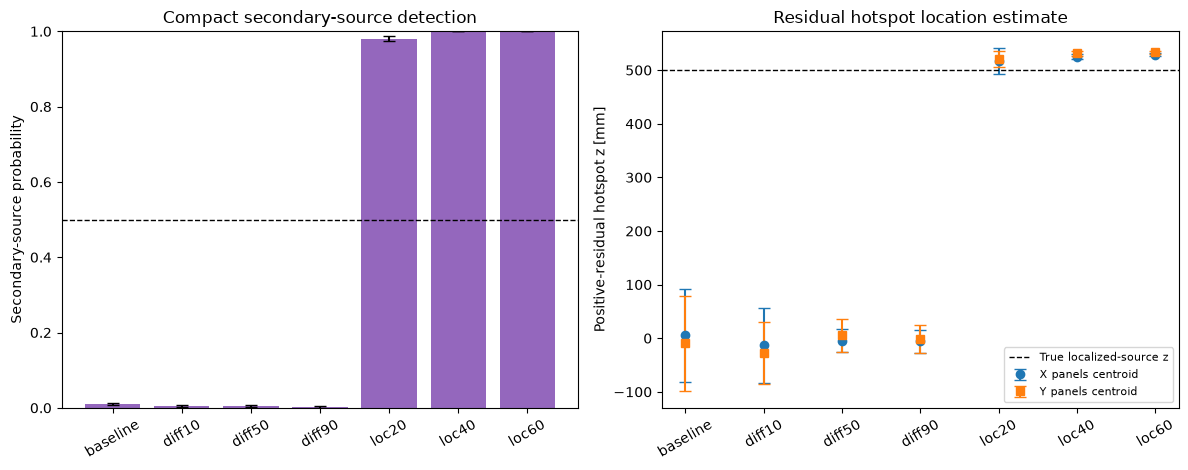

,case,label,secondary_probability_mean,secondary_probability_sd,call_fraction,zhat_combined_mean,zhat_combined_sd,n_reported_locations
0,baseline,No diffusion baseline,0.009674,2.961613e-03,0.0,NaN,NaN,0
1,diff10,Source diffusion 10%,0.004999,2.925527e-03,0.0,NaN,NaN,0
2,diff50,Source diffusion 50%,0.004338,3.012452e-03,0.0,NaN,NaN,0
3,diff90,Source diffusion 90%,0.002682,3.188829e-03,0.0,NaN,NaN,0
4,loc20,Localised secondary 20%,0.980920,5.956663e-03,1.0,518.944535,18.963008,10
5,loc40,Localised secondary 40%,0.999946,1.830498e-05,1.0,528.139992,3.414786,10
6,loc60,Localised secondary 60%,1.000000,3.480862e-08,1.0,531.123333,2.197421,10


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/secondary_source_gated_detection_and_location.png


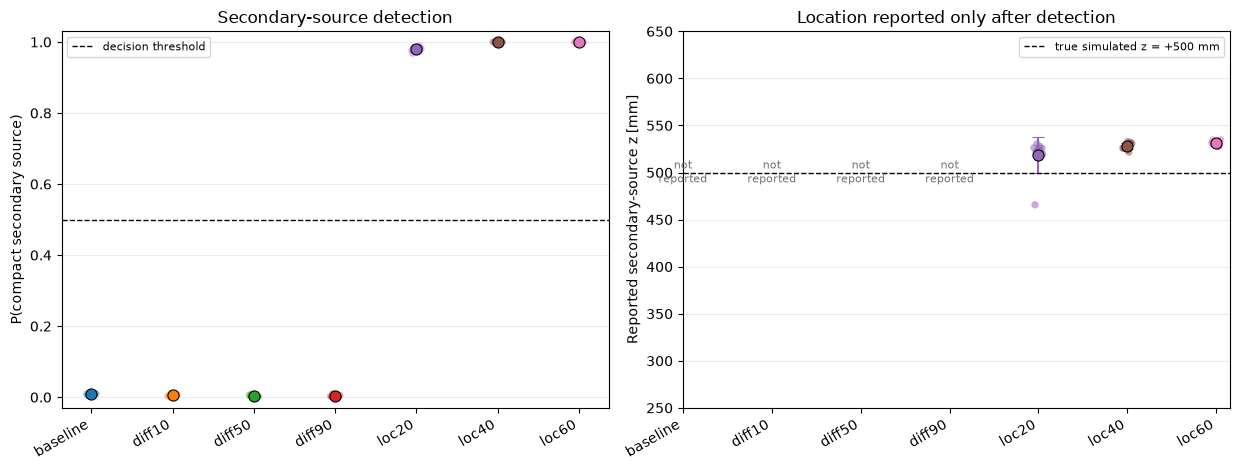

Saved figure: docs/figures/Simulation_output_signal_inference_metrics/secondary_source_gated_detection_and_location_loc_cases.png


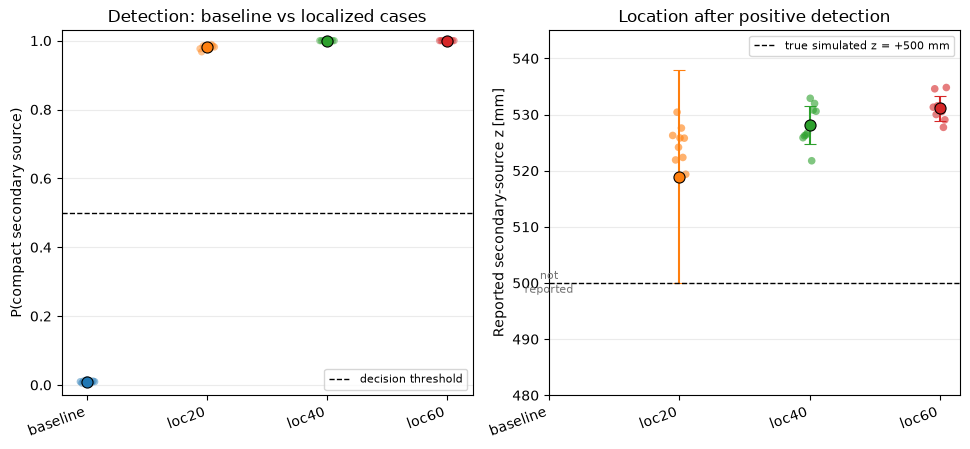

,case,label,true_secondary,true_z_mm,call_fraction,forced_zhat_mean,forced_zhat_sd,reported_zhat_mean,reported_zhat_sd
0,baseline,No diffusion baseline,0,NaN,0.0,-2.023615,53.387364,NaN,NaN
1,diff10,Source diffusion 10%,0,NaN,0.0,-20.059233,37.617770,NaN,NaN
2,diff50,Source diffusion 50%,0,NaN,0.0,0.391674,21.075161,NaN,NaN
3,diff90,Source diffusion 90%,0,NaN,0.0,-3.967789,21.215665,NaN,NaN
4,loc20,Localised secondary 20%,1,500.0,1.0,518.944535,18.963008,518.944535,18.963008
5,loc40,Localised secondary 40%,1,500.0,1.0,528.139992,3.414786,528.139992,3.414786
6,loc60,Localised secondary 60%,1,500.0,1.0,531.123333,2.197421,531.123333,2.197421


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/secondary_source_predicted_vs_true_position_diagnostic.png


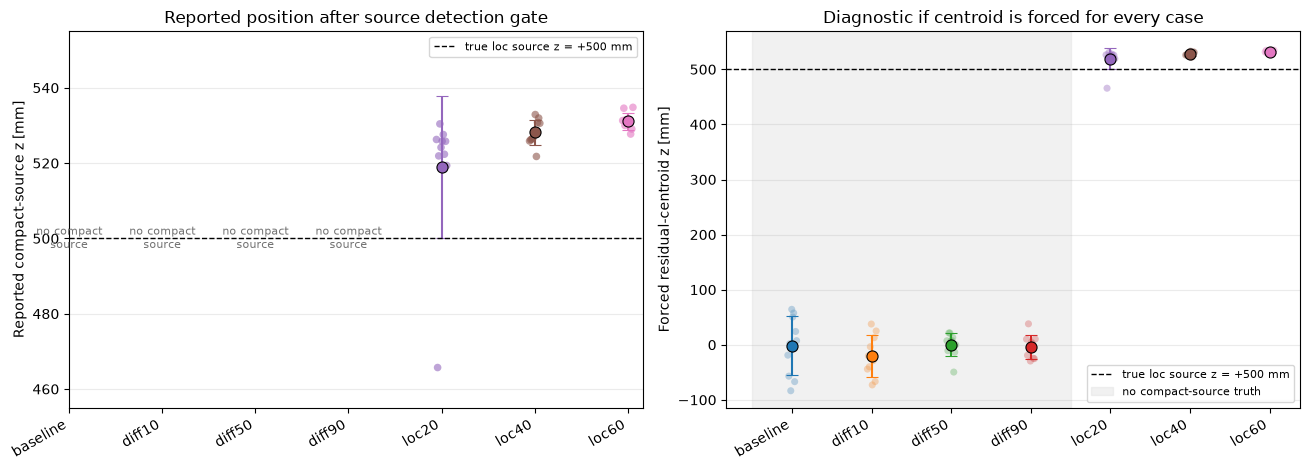

In [56]:
secondary_feature_cols = []
secondary_feature_cols += columns_matching(features_df, prefixes=('PosY_', 'NegY_', 'Ysum_', 'Xsum_', 'All_'), contains=('residual_bin_',))
secondary_feature_cols += [
    col for col in features_df.columns
    if any(col.endswith(suffix) for suffix in [
        'positive_residual_per_event', 'positive_residual_centroid_z_mm',
        'positive_residual_peak_z_mm', 'positive_residual_peak_per_event',
        'secondary_roi_rate_per_event', 'residual_l1_per_event', 'z_std_mm', 'z_q80_width_mm'
    ])
]
secondary_feature_cols += ['Y_panel_asymmetry', 'X_panel_asymmetry', 'Y_to_X_rate_ratio', 'detected_rate_all_per_event']
secondary_feature_cols = sorted(set(secondary_feature_cols))

sec_df = features_df[features_df['case'].isin(secondary_training_cases)].copy()
X_sec = sec_df[secondary_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
y_sec = sec_df['secondary_present_true'].to_numpy(dtype=int)

sec_prob = np.zeros(len(sec_df))
sec_pred = np.zeros(len(sec_df), dtype=int)
for train_idx, test_idx in LeaveOneOut().split(X_sec):
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', C=0.5, max_iter=2000)
    )
    clf.fit(X_sec.iloc[train_idx], y_sec[train_idx])
    sec_prob[test_idx] = clf.predict_proba(X_sec.iloc[test_idx])[:, 1]
    sec_pred[test_idx] = (sec_prob[test_idx] >= 0.5).astype(int)

sec_df['secondary_probability_cv'] = sec_prob
sec_df['secondary_present_pred_cv'] = sec_pred

print(f"LOO accuracy: {accuracy_score(y_sec, sec_pred):.3f}")
print(f"LOO ROC AUC: {roc_auc_score(y_sec, sec_prob):.3f}")
print('Confusion matrix [[true negative, false positive], [false negative, true positive]]:')
display(pd.DataFrame(confusion_matrix(y_sec, sec_pred), index=['true_no_secondary', 'true_secondary'], columns=['pred_no_secondary', 'pred_secondary']))

secondary_summary = sec_df.groupby('case', sort=False).agg(
    label=('label', 'first'),
    true_secondary=('secondary_present_true', 'first'),
    true_secondary_fraction=('secondary_fraction_true', 'first'),
    secondary_probability_mean=('secondary_probability_cv', 'mean'),
    secondary_probability_sd=('secondary_probability_cv', 'std'),
    predicted_positive_fraction=('secondary_present_pred_cv', 'mean'),
    All_peak_z_mm_mean=('All_positive_residual_peak_z_mm', 'mean'),
    All_peak_z_mm_sd=('All_positive_residual_peak_z_mm', 'std'),
    Xsum_centroid_z_mm_mean=('Xsum_positive_residual_centroid_z_mm', 'mean'),
    Xsum_centroid_z_mm_sd=('Xsum_positive_residual_centroid_z_mm', 'std'),
    Ysum_centroid_z_mm_mean=('Ysum_positive_residual_centroid_z_mm', 'mean'),
    Ysum_centroid_z_mm_sd=('Ysum_positive_residual_centroid_z_mm', 'std'),
).reset_index()

display(secondary_summary)
sec_df[['case', 'rep', 'secondary_present_true', 'secondary_probability_cv', 'secondary_present_pred_cv', 'All_positive_residual_peak_z_mm', 'Xsum_positive_residual_centroid_z_mm', 'Ysum_positive_residual_centroid_z_mm']].to_csv(metrics_output_dir / 'secondary_source_cv_predictions.csv', index=False)
secondary_summary.to_csv(metrics_output_dir / 'secondary_source_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_sec = secondary_summary.set_index('case').loc[[key for key in case_order if key in secondary_summary['case'].values]].reset_index()
axes[0].bar(plot_sec['case'], plot_sec['secondary_probability_mean'], yerr=plot_sec['secondary_probability_sd'], capsize=4, color='tab:purple')
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Secondary-source probability')
axes[0].set_title('Compact secondary-source detection')
axes[0].tick_params(axis='x', rotation=30)

axes[1].errorbar(plot_sec['case'], plot_sec['Xsum_centroid_z_mm_mean'], yerr=plot_sec['Xsum_centroid_z_mm_sd'], fmt='o', capsize=4, label='X panels centroid')
axes[1].errorbar(plot_sec['case'], plot_sec['Ysum_centroid_z_mm_mean'], yerr=plot_sec['Ysum_centroid_z_mm_sd'], fmt='s', capsize=4, label='Y panels centroid')
axes[1].axhline(500, color='black', linestyle='--', linewidth=1, label='True localized-source z')
axes[1].set_ylabel('Positive-residual hotspot z [mm]')
axes[1].set_title('Residual hotspot location estimate')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'secondary_source_detection_and_location')
plt.show()


# Gated view: detection is shown for all cases, but location is reported only when
# the secondary-source classifier calls the repetition positive. This avoids
# assigning physical meaning to residual centroids from diffuse/no-secondary cases.
gated_location_df = sec_df.copy()
gated_location_df['zhat_combined_z_mm'] = gated_location_df[
    ['Xsum_positive_residual_centroid_z_mm', 'Ysum_positive_residual_centroid_z_mm']
].mean(axis=1)
gated_location_df.loc[~gated_location_df['secondary_present_pred_cv'].astype(bool), 'zhat_combined_z_mm'] = np.nan
gated_location_df.to_csv(metrics_output_dir / 'secondary_source_gated_location_by_repetition.csv', index=False)

gated_summary = (
    gated_location_df.groupby('case', sort=False)
    .agg(
        label=('label', 'first'),
        secondary_probability_mean=('secondary_probability_cv', 'mean'),
        secondary_probability_sd=('secondary_probability_cv', 'std'),
        call_fraction=('secondary_present_pred_cv', 'mean'),
        zhat_combined_mean=('zhat_combined_z_mm', 'mean'),
        zhat_combined_sd=('zhat_combined_z_mm', 'std'),
        n_reported_locations=('zhat_combined_z_mm', lambda x: int(np.isfinite(x).sum())),
    )
    .reindex(case_order)
    .reset_index()
)
gated_summary.to_csv(metrics_output_dir / 'secondary_source_gated_location_summary.csv', index=False)
display(gated_summary)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
plot_order = [key for key in case_order if key in gated_location_df['case'].unique()]
x_positions = np.arange(len(plot_order), dtype=float)
case_color_map = dict(zip(plot_order, plt.cm.tab10(np.arange(len(plot_order)))))

ax = axes[0]
for i, case_key in enumerate(plot_order):
    values = gated_location_df.loc[gated_location_df['case'] == case_key, 'secondary_probability_cv'].to_numpy(dtype=float)
    jitter = np.linspace(-0.06, 0.06, len(values)) if len(values) > 1 else np.array([0.0])
    color = case_color_map[case_key]
    ax.scatter(i + jitter, values, s=24, color=color, alpha=0.40, edgecolor='none')
    ax.errorbar(i, np.nanmean(values), yerr=np.nanstd(values, ddof=1), fmt='o', ms=8, color=color, mec='black', mew=0.8, capsize=4)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='decision threshold')
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_order, rotation=30, ha='right')
ax.set_ylim(-0.03, 1.03)
ax.set_ylabel('P(compact secondary source)')
ax.set_title('Secondary-source detection')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)

ax = axes[1]
for i, case_key in enumerate(plot_order):
    values = gated_location_df.loc[gated_location_df['case'] == case_key, 'zhat_combined_z_mm'].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    color = case_color_map[case_key]
    if finite.size:
        jitter = np.linspace(-0.05, 0.05, finite.size) if finite.size > 1 else np.array([0.0])
        ax.scatter(i + jitter, finite, s=28, color=color, alpha=0.55, edgecolor='none')
        ax.errorbar(i, np.nanmean(finite), yerr=np.nanstd(finite, ddof=1) if finite.size > 1 else 0.0, fmt='o', ms=8, color=color, mec='black', mew=0.8, capsize=4)
    else:
        ax.text(i, 500, 'not\nreported', ha='center', va='center', color='0.45', fontsize=8)
ax.axhline(500, color='black', linestyle='--', linewidth=1, label='true simulated z = +500 mm')
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_order, rotation=30, ha='right')
ax.set_ylim(250, 650)
ax.set_ylabel('Reported secondary-source z [mm]')
ax.set_title('Location reported only after detection')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'secondary_source_gated_detection_and_location')
plt.show()


# Loc-focused version for presentation: baseline plus localized-source cases only.
loc_focused_cases = [case for case in ['baseline', 'loc20', 'loc40', 'loc60'] if case in gated_location_df['case'].unique()]
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.6))
x_positions = np.arange(len(loc_focused_cases), dtype=float)
loc_case_color_map = dict(zip(loc_focused_cases, plt.cm.tab10(np.arange(len(loc_focused_cases)))))

ax = axes[0]
for i, case_key in enumerate(loc_focused_cases):
    values = gated_location_df.loc[gated_location_df['case'] == case_key, 'secondary_probability_cv'].to_numpy(dtype=float)
    jitter = np.linspace(-0.06, 0.06, len(values)) if len(values) > 1 else np.array([0.0])
    color = loc_case_color_map[case_key]
    ax.scatter(i + jitter, values, s=28, color=color, alpha=0.45, edgecolor='none')
    ax.errorbar(i, np.nanmean(values), yerr=np.nanstd(values, ddof=1), fmt='o', ms=8, color=color, mec='black', mew=0.8, capsize=4)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='decision threshold')
ax.set_xticks(x_positions)
ax.set_xticklabels(loc_focused_cases, rotation=20, ha='right')
ax.set_ylim(-0.03, 1.03)
ax.set_ylabel('P(compact secondary source)')
ax.set_title('Detection: baseline vs localized cases')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)

ax = axes[1]
for i, case_key in enumerate(loc_focused_cases):
    values = gated_location_df.loc[gated_location_df['case'] == case_key, 'zhat_combined_z_mm'].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    color = loc_case_color_map[case_key]
    if finite.size:
        jitter = np.linspace(-0.05, 0.05, finite.size) if finite.size > 1 else np.array([0.0])
        ax.scatter(i + jitter, finite, s=30, color=color, alpha=0.60, edgecolor='none')
        ax.errorbar(i, np.nanmean(finite), yerr=np.nanstd(finite, ddof=1) if finite.size > 1 else 0.0, fmt='o', ms=8, color=color, mec='black', mew=0.8, capsize=4)
    else:
        ax.text(i, 500, 'not\nreported', ha='center', va='center', color='0.45', fontsize=8)
ax.axhline(500, color='black', linestyle='--', linewidth=1, label='true simulated z = +500 mm')
ax.set_xticks(x_positions)
ax.set_xticklabels(loc_focused_cases, rotation=20, ha='right')
ax.set_ylim(480, 545)
ax.set_ylabel('Reported secondary-source z [mm]')
ax.set_title('Location after positive detection')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'secondary_source_gated_detection_and_location_loc_cases')
plt.show()


# Predicted-vs-true z-position diagnostic.
# A compact-source z truth exists only for loc* cases. For baseline/diffuse cases,
# the forced residual centroid is shown separately as a diagnostic, not a reported source location.
position_diagnostic_df = sec_df.copy()
position_diagnostic_df['zhat_forced_combined_z_mm'] = position_diagnostic_df[
    ['Xsum_positive_residual_centroid_z_mm', 'Ysum_positive_residual_centroid_z_mm']
].mean(axis=1)
position_diagnostic_df['zhat_reported_z_mm'] = position_diagnostic_df['zhat_forced_combined_z_mm']
position_diagnostic_df.loc[
    ~position_diagnostic_df['secondary_present_pred_cv'].astype(bool),
    'zhat_reported_z_mm'
] = np.nan
position_diagnostic_df.to_csv(metrics_output_dir / 'secondary_source_position_diagnostic_by_repetition.csv', index=False)

position_summary = (
    position_diagnostic_df.groupby('case', sort=False)
    .agg(
        label=('label', 'first'),
        true_secondary=('secondary_present_true', 'first'),
        true_z_mm=('secondary_z_mm_true', 'first'),
        call_fraction=('secondary_present_pred_cv', 'mean'),
        forced_zhat_mean=('zhat_forced_combined_z_mm', 'mean'),
        forced_zhat_sd=('zhat_forced_combined_z_mm', 'std'),
        reported_zhat_mean=('zhat_reported_z_mm', 'mean'),
        reported_zhat_sd=('zhat_reported_z_mm', 'std'),
    )
    .reindex(case_order)
    .reset_index()
)
position_summary.to_csv(metrics_output_dir / 'secondary_source_position_diagnostic_summary.csv', index=False)
display(position_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
plot_order = [key for key in case_order if key in position_diagnostic_df['case'].unique()]
x_positions = np.arange(len(plot_order), dtype=float)
position_case_colors = dict(zip(plot_order, plt.cm.tab10(np.arange(len(plot_order)))))

ax = axes[0]
for i, case_key in enumerate(plot_order):
    sub = position_diagnostic_df[position_diagnostic_df['case'] == case_key]
    values = sub['zhat_reported_z_mm'].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    color = position_case_colors[case_key]
    if finite.size:
        jitter = np.linspace(-0.055, 0.055, finite.size) if finite.size > 1 else np.array([0.0])
        ax.scatter(i + jitter, finite, s=30, color=color, alpha=0.60, edgecolor='none')
        ax.errorbar(
            i,
            np.nanmean(finite),
            yerr=np.nanstd(finite, ddof=1) if finite.size > 1 else 0.0,
            fmt='o', ms=8, color=color, mec='black', mew=0.8, capsize=4,
        )
    else:
        ax.text(i, 500, 'no compact\nsource', ha='center', va='center', color='0.45', fontsize=8)
ax.axhline(500, color='black', linestyle='--', linewidth=1, label='true loc source z = +500 mm')
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_order, rotation=30, ha='right')
ax.set_ylim(455, 555)
ax.set_ylabel('Reported compact-source z [mm]')
ax.set_title('Reported position after source detection gate')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)

ax = axes[1]
for i, case_key in enumerate(plot_order):
    sub = position_diagnostic_df[position_diagnostic_df['case'] == case_key]
    values = sub['zhat_forced_combined_z_mm'].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    color = position_case_colors[case_key]
    jitter = np.linspace(-0.055, 0.055, finite.size) if finite.size > 1 else np.array([0.0])
    ax.scatter(i + jitter, finite, s=26, color=color, alpha=0.40, edgecolor='none')
    ax.errorbar(
        i,
        np.nanmean(finite),
        yerr=np.nanstd(finite, ddof=1) if finite.size > 1 else 0.0,
        fmt='o', ms=8, color=color, mec='black', mew=0.8, capsize=4,
    )
ax.axhline(500, color='black', linestyle='--', linewidth=1, label='true loc source z = +500 mm')
ax.axvspan(-0.5, 3.5, color='0.85', alpha=0.35, label='no compact-source truth')
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_order, rotation=30, ha='right')
ax.set_ylabel('Forced residual-centroid z [mm]')
ax.set_title('Diagnostic if centroid is forced for every case')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'secondary_source_predicted_vs_true_position_diagnostic')
plt.show()


## Localised-source position residuals

The localised cases all use the same true secondary-source center (`z = 500 mm`), so the clearest validation view is the localisation residual (`predicted z - true z`). The outputs below include a case-level residual summary, a three-panel residual histogram, and single-case residual histograms with Gaussian fits.


,case,label,true_z_mm,predicted_z_mean_mm,predicted_z_sd_mm,bias_mm,residual_sd_mm,secondary_probability,call_fraction,n_reported_locations
0,loc20,Localised secondary 20%,500.0,518.944535,18.963008,18.944535,18.963008,0.980920,1.0,10
1,loc40,Localised secondary 40%,500.0,528.139992,3.414786,28.139992,3.414786,0.999946,1.0,10
2,loc60,Localised secondary 60%,500.0,531.123333,2.197421,31.123333,2.197421,1.000000,1.0,10


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/localized_source_position_bias_summary.png


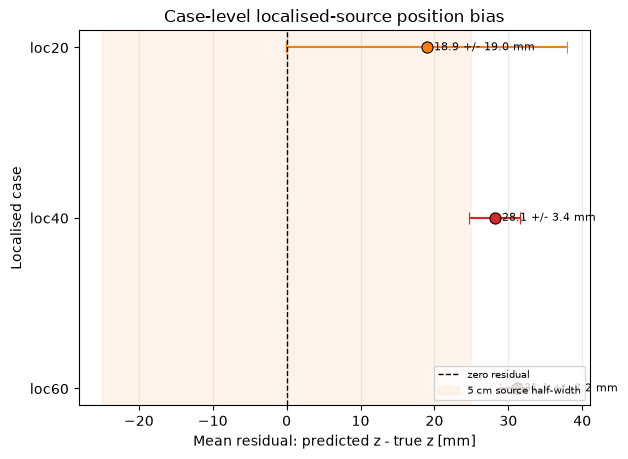

Saved figure: docs/figures/Simulation_output_signal_inference_metrics/localized_source_position_residual_histogram.png


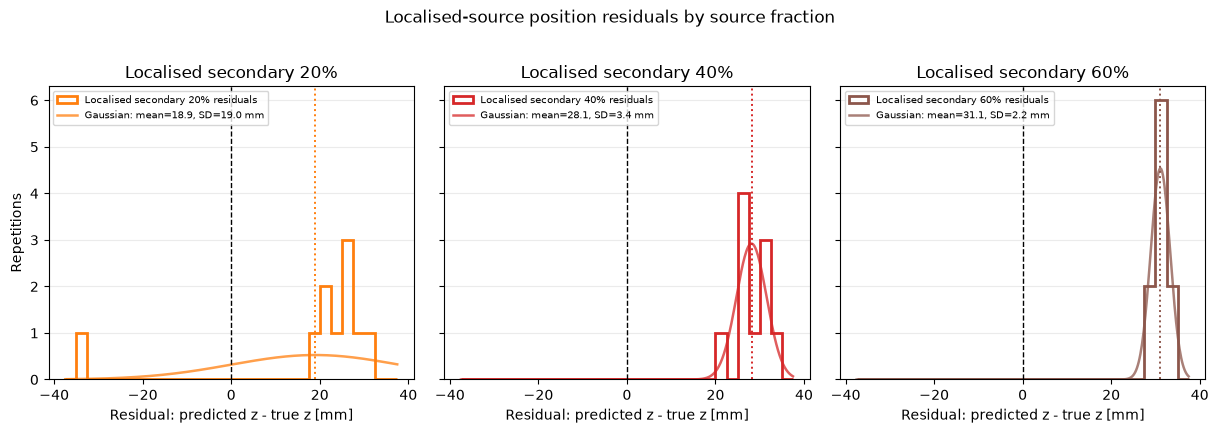

Saved figure: docs/figures/Simulation_output_signal_inference_metrics/localized_source_position_residual_histogram_loc20.png


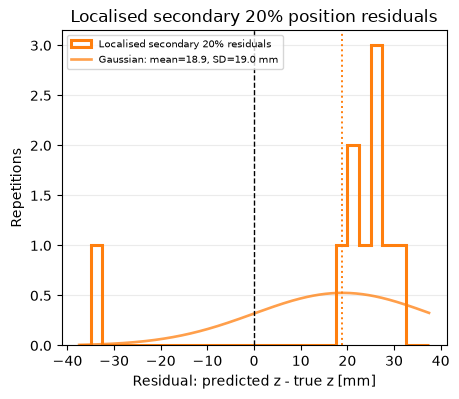

Saved figure: docs/figures/Simulation_output_signal_inference_metrics/localized_source_position_residual_histogram_loc40.png


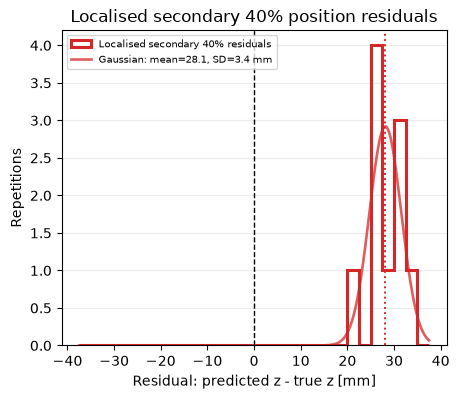

Saved figure: docs/figures/Simulation_output_signal_inference_metrics/localized_source_position_residual_histogram_loc60.png


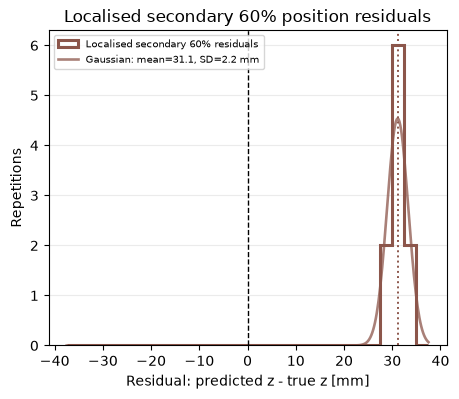

In [57]:
# Localised-source residual validation for abstract-style reporting.
# Figure 1: case-level residual mean +/- repetition SD.
# Figure 2: per-case step histograms with Gaussian fits.
localized_position_rows = []
localized_residual_rows = []
for case_key in case_order:
    if not bool(analysis_cases[case_key]['secondary_present']):
        continue
    sec_vals = position_diagnostic_df[
        (position_diagnostic_df['case'] == case_key)
        & position_diagnostic_df['zhat_reported_z_mm'].notna()
    ].copy()
    if sec_vals.empty:
        continue
    true_z = analysis_cases[case_key]['secondary_z_mm']
    sec_vals['position_residual_mm'] = sec_vals['zhat_reported_z_mm'] - true_z
    for row in sec_vals.itertuples(index=False):
        localized_residual_rows.append({
            'case': case_key,
            'rep': row.rep,
            'true_z_mm': true_z,
            'predicted_z_mm': row.zhat_reported_z_mm,
            'position_residual_mm': row.position_residual_mm,
            'secondary_probability': row.secondary_probability_cv,
        })
    localized_position_rows.append({
        'case': case_key,
        'label': case_labels.get(case_key, case_key),
        'true_z_mm': true_z,
        'predicted_z_mean_mm': sec_vals['zhat_reported_z_mm'].mean(),
        'predicted_z_sd_mm': sec_vals['zhat_reported_z_mm'].std(ddof=1),
        'bias_mm': sec_vals['position_residual_mm'].mean(),
        'residual_sd_mm': sec_vals['position_residual_mm'].std(ddof=1),
        'secondary_probability': sec_vals['secondary_probability_cv'].mean(),
        'call_fraction': sec_vals['secondary_present_pred_cv'].mean(),
        'n_reported_locations': len(sec_vals),
    })

localized_position_prediction_df = pd.DataFrame(localized_position_rows)
localized_position_residuals_df = pd.DataFrame(localized_residual_rows)
localized_position_prediction_df.to_csv(metrics_output_dir / 'localized_source_position_prediction.csv', index=False)
localized_position_residuals_df.to_csv(metrics_output_dir / 'localized_source_position_residuals.csv', index=False)
display(localized_position_prediction_df)

source_component_map_df = localized_position_prediction_df.rename(columns={
    'predicted_z_mean_mm': 'z_mean_mm',
    'predicted_z_sd_mm': 'z_sd_mm',
})[['case', 'z_mean_mm', 'z_sd_mm', 'n_reported_locations']].copy()
source_component_map_df.insert(1, 'component', 'localised secondary component')
source_component_map_df['strength_proxy'] = np.nan
source_component_map_df['strength_label'] = 'not encoded in figure'
source_component_map_df = source_component_map_df.rename(columns={'n_reported_locations': 'n'})
source_component_map_df.to_csv(metrics_output_dir / 'combined_source_position_map.csv', index=False)

case_colors = {'loc20': 'tab:orange', 'loc40': 'tab:red', 'loc50': 'tab:purple', 'loc60': 'tab:brown'}

fig, ax = plt.subplots(figsize=(6.4, 4.7))
plot_df = localized_position_prediction_df.copy()
y_positions = np.arange(len(plot_df))
for i, row in plot_df.iterrows():
    ax.errorbar(
        row['bias_mm'], i,
        xerr=row['residual_sd_mm'] if np.isfinite(row['residual_sd_mm']) else 0.0,
        fmt='o', ms=8, capsize=4,
        color=case_colors.get(row['case'], '0.4'), mec='black', mew=0.8,
    )
    ax.text(row['bias_mm'] + 1.0, i, f"{row['bias_mm']:.1f} +/- {row['residual_sd_mm']:.1f} mm", va='center', fontsize=8)
ax.axvline(0, color='black', linestyle='--', linewidth=1.0, label='zero residual')
ax.axvspan(-25, 25, color='tab:orange', alpha=0.08, label='5 cm source half-width')
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df['case'])
ax.invert_yaxis()
ax.set_xlabel('Mean residual: predicted z - true z [mm]')
ax.set_ylabel('Localised case')
ax.set_title('Case-level localised-source position bias')
ax.grid(axis='x', alpha=0.25)
ax.legend(fontsize=7.5, loc='lower right')
plt.tight_layout()
save_figure(fig, 'localized_source_position_bias_summary')
plt.show()

def localised_case_sort_key(case_key):
    match = re.search(r'loc(\d+)', str(case_key))
    return (0, int(match.group(1))) if match else (1, str(case_key))

available_hist_cases = set(localized_position_residuals_df.get('case', []))
hist_cases = sorted(available_hist_cases, key=localised_case_sort_key)
n_hist_cases = max(len(hist_cases), 1)
fig, axes = plt.subplots(1, n_hist_cases, figsize=(4.1 * n_hist_cases, 4.2), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
if not localized_position_residuals_df.empty:
    all_residuals = localized_position_residuals_df['position_residual_mm'].to_numpy(dtype=float)
    bin_min = np.floor((np.nanmin(all_residuals) - 2.5) / 2.5) * 2.5
    bin_max = np.ceil((np.nanmax(all_residuals) + 2.5) / 2.5) * 2.5
    if bin_max <= bin_min:
        bin_max = bin_min + 5.0
    bins = np.arange(bin_min, bin_max + 2.5, 2.5)
    for ax, case_key in zip(axes, hist_cases):
        case_residuals = localized_position_residuals_df.loc[
            localized_position_residuals_df['case'] == case_key,
            'position_residual_mm',
        ].to_numpy(dtype=float)
        color = case_colors.get(case_key, '0.3')
        counts, edges, _ = ax.hist(
            case_residuals,
            bins=bins,
            histtype='step',
            linewidth=2.0,
            color=color,
            label=f"{case_labels.get(case_key, case_key)} residuals",
        )
        mu = float(np.mean(case_residuals))
        sigma = float(np.std(case_residuals, ddof=1)) if len(case_residuals) > 1 else np.nan
        if np.isfinite(sigma) and sigma > 0:
            x = np.linspace(edges[0], edges[-1], 400)
            bin_width = edges[1] - edges[0]
            gaussian_counts = len(case_residuals) * bin_width * np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
            ax.plot(x, gaussian_counts, color=color, linewidth=1.8, alpha=0.75, label=f'Gaussian: mean={mu:.1f}, SD={sigma:.1f} mm')
        else:
            ax.text(0.5, 0.92, 'Gaussian fit unavailable', transform=ax.transAxes, ha='center', va='top', fontsize=8)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.0)
        ax.axvline(mu, color=color, linestyle=':', linewidth=1.4)
        ax.set_title(case_labels.get(case_key, case_key))
        ax.grid(axis='y', alpha=0.25)
        ax.legend(fontsize=7.0, loc='upper left')
else:
    axes[0].text(0.5, 0.5, 'No localized residuals available', transform=axes[0].transAxes, ha='center', va='center')
for ax in axes:
    ax.set_xlabel('Residual: predicted z - true z [mm]')
axes[0].set_ylabel('Repetitions')
fig.suptitle('Localised-source position residuals by source fraction', y=1.02)
plt.tight_layout()
save_figure(fig, 'localized_source_position_residual_histogram')
plt.show()

# Single-case versions for flexible poster layout.
for case_key in hist_cases:
    case_residuals = localized_position_residuals_df.loc[
        localized_position_residuals_df['case'] == case_key,
        'position_residual_mm',
    ].to_numpy(dtype=float)
    if len(case_residuals) == 0:
        continue
    color = case_colors.get(case_key, '0.3')
    fig, ax = plt.subplots(figsize=(4.7, 4.1))
    counts, edges, _ = ax.hist(
        case_residuals,
        bins=bins,
        histtype='step',
        linewidth=2.2,
        color=color,
        label=f"{case_labels.get(case_key, case_key)} residuals",
    )
    mu = float(np.mean(case_residuals))
    sigma = float(np.std(case_residuals, ddof=1)) if len(case_residuals) > 1 else np.nan
    if np.isfinite(sigma) and sigma > 0:
        x = np.linspace(edges[0], edges[-1], 400)
        bin_width = edges[1] - edges[0]
        gaussian_counts = len(case_residuals) * bin_width * np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
        ax.plot(x, gaussian_counts, color=color, linewidth=1.9, alpha=0.75, label=f'Gaussian: mean={mu:.1f}, SD={sigma:.1f} mm')
    else:
        ax.text(0.5, 0.92, 'Gaussian fit unavailable', transform=ax.transAxes, ha='center', va='top', fontsize=8)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.0)
    ax.axvline(mu, color=color, linestyle=':', linewidth=1.4)
    ax.set_xlabel('Residual: predicted z - true z [mm]')
    ax.set_ylabel('Repetitions')
    ax.set_title(f"{case_labels.get(case_key, case_key)} position residuals")
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=7.2, loc='upper left')
    plt.tight_layout()
    save_figure(fig, f'localized_source_position_residual_histogram_{case_key}')
    plt.show()


## Time-to-detect estimates

This section estimates how long a cumulative observation window must be before each signal becomes distinguishable from baseline. It uses direct detector observables at each time cut rather than retraining the ML models: y-panel asymmetry for redistribution, +Y central-ROI rate for applicator depletion, and displaced-ROI rate for secondary-source excess. The reported time is the first window where the candidate-baseline separation exceeds a chosen Z threshold.


,case,observable,observable_label,meaning,first_time_label,first_time_s,z_at_first_time,threshold
0,diff10,redistribution_y_asymmetry,Y asymmetry change,diffusion/redistribution shape change,6 h,21600.0,-5.190660,3 sigma
1,diff10,applicator_central_depletion,+Y central ROI depletion,remaining applicator signal differs from baseline,6 h,21600.0,-3.190830,3 sigma
2,diff10,secondary_displaced_roi_excess,displaced ROI excess,extra signal in secondary-search region,1 d,86400.0,4.904332,3 sigma
3,diff50,redistribution_y_asymmetry,Y asymmetry change,diffusion/redistribution shape change,2 h,7200.0,-5.921859,3 sigma
4,diff50,applicator_central_depletion,+Y central ROI depletion,remaining applicator signal differs from baseline,30 min,1800.0,-3.567078,3 sigma
5,diff50,secondary_displaced_roi_excess,displaced ROI excess,extra signal in secondary-search region,2 h,7200.0,4.747872,3 sigma
6,diff90,redistribution_y_asymmetry,Y asymmetry change,diffusion/redistribution shape change,30 min,1800.0,-3.497997,3 sigma
7,diff90,applicator_central_depletion,+Y central ROI depletion,remaining applicator signal differs from baseline,30 min,1800.0,-3.283121,3 sigma
8,diff90,secondary_displaced_roi_excess,displaced ROI excess,extra signal in secondary-search region,1 h,3600.0,3.294820,3 sigma
9,loc20,redistribution_y_asymmetry,Y asymmetry change,diffusion/redistribution shape change,6 h,21600.0,-5.713573,3 sigma


Earliest cumulative time reaching 5σ separation from baseline:


observable_label,central source depletion,redistribution / diffusion,localized-source excess
case,,,
diff10,2 d,6 h,2 d
diff50,2 h,2 h,6 h
diff90,1 h,1 h,2 h
loc20,6 h,6 h,6 h
loc40,6 h,2 h,1 h
loc60,2 h,2 h,1 h


Earliest cumulative time reaching 3σ separation from baseline:


observable_label,central source depletion,redistribution / diffusion,localized-source excess
case,,,
diff10,6 h,6 h,1 d
diff50,30 min,2 h,2 h
diff90,30 min,30 min,1 h
loc20,2 h,6 h,2 h
loc40,2 h,2 h,30 min
loc60,2 h,1 h,30 min


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/time_to_detect_5sigma_summary.png


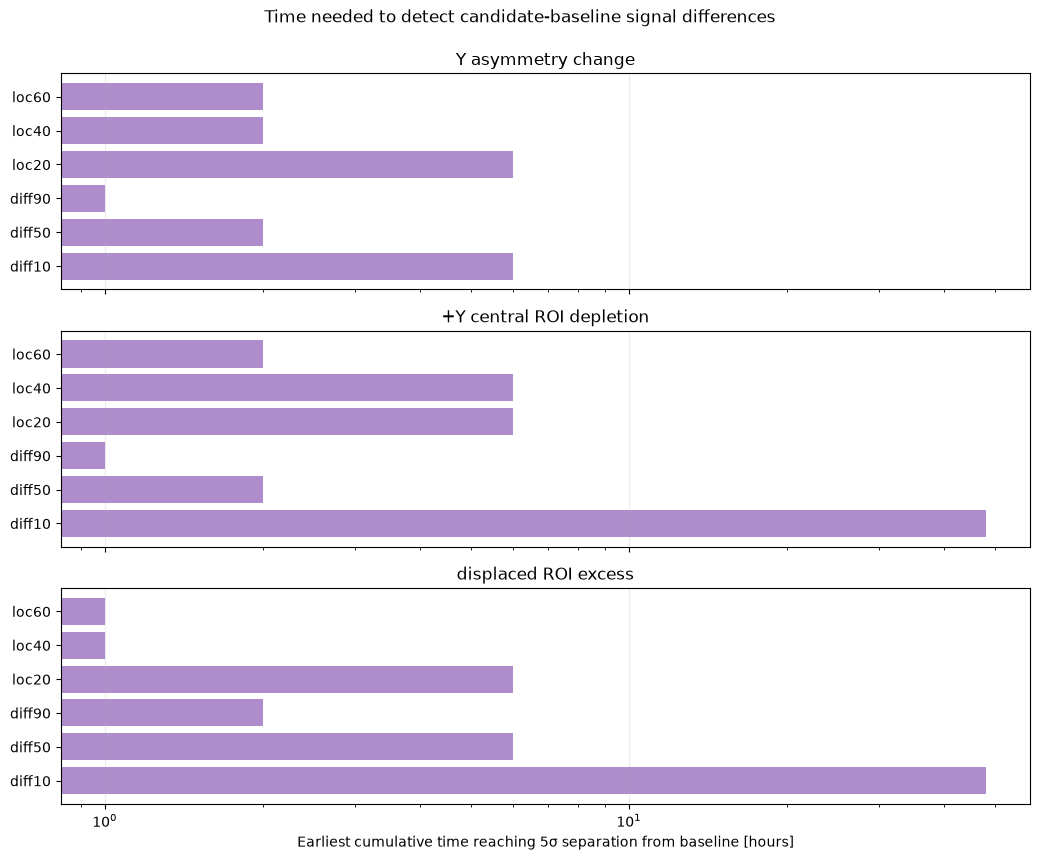

Saved figure: docs/figures/Simulation_output_signal_inference_metrics/secondary_displaced_roi_zscore_vs_time.png


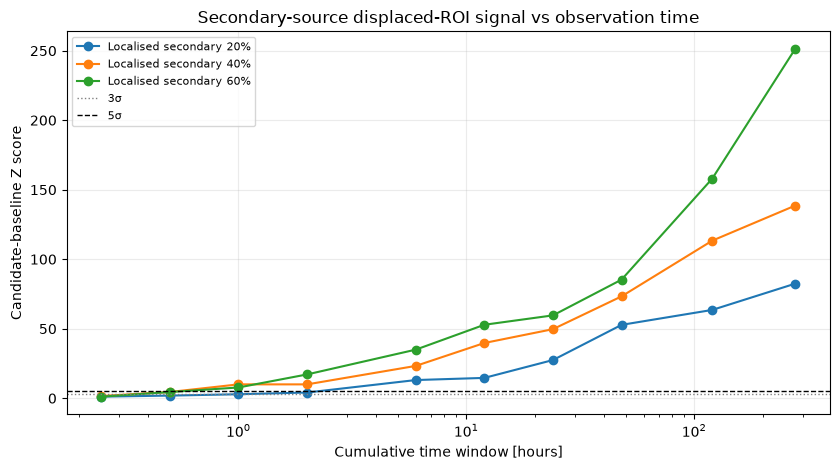

In [58]:
# Time-to-detect diagnostics.
# These are direct statistical separations from baseline at cumulative time cuts.
time_detection_windows = [
    ('15 min', 15 * 60.0),
    ('30 min', 30 * 60.0),
    ('1 h', 1 * 3600.0),
    ('2 h', 2 * 3600.0),
    ('6 h', 6 * 3600.0),
    ('12 h', 12 * 3600.0),
    ('1 d', 24 * 3600.0),
    ('2 d', 2 * 24 * 3600.0),
    ('5 d', 5 * 24 * 3600.0),
    ('1e6 s', 1.0e6),
]

def count_rate_in_window(rep, panels, time_limit_s, z_roi=None):
    selected = select_entries(rep, panels, time_limit_s=time_limit_s)
    if z_roi is not None:
        lo, hi = z_roi
        selected = selected[(selected['z_mm'] >= lo) & (selected['z_mm'] <= hi)]
    return len(selected) / rep['n_events']

def y_asymmetry_in_window(rep, time_limit_s):
    pos = count_rate_in_window(rep, ['physPhotonDetectorPosY'], time_limit_s)
    neg = count_rate_in_window(rep, ['physPhotonDetectorNegY'], time_limit_s)
    denom = pos + neg
    return (pos - neg) / denom if denom > 0 else np.nan

def secondary_roi_rate_in_window(rep, time_limit_s):
    # Use Xsum+Ysum in the displaced z ROI. This is a detection-strength proxy;
    # location is still handled by the gated residual-centroid estimator above.
    panels = panel_sets['Xsum'] + panel_sets['Ysum']
    return count_rate_in_window(rep, panels, time_limit_s, z_roi=secondary_search_z_roi_mm)

def observable_values_for_case(case_key, observable_name, time_limit_s):
    vals = []
    for rep in cases.get(case_key, []):
        if observable_name == 'redistribution_y_asymmetry':
            vals.append(y_asymmetry_in_window(rep, time_limit_s))
        elif observable_name == 'applicator_central_depletion':
            vals.append(count_rate_in_window(rep, ['physPhotonDetectorPosY'], time_limit_s, z_roi=central_z_roi_mm))
        elif observable_name == 'secondary_displaced_roi_excess':
            vals.append(secondary_roi_rate_in_window(rep, time_limit_s))
        else:
            raise ValueError(observable_name)
    return np.asarray(vals, dtype=float)

def separation_z(candidate_values, baseline_values):
    candidate_values = candidate_values[np.isfinite(candidate_values)]
    baseline_values = baseline_values[np.isfinite(baseline_values)]
    if len(candidate_values) == 0 or len(baseline_values) == 0:
        return np.nan, np.nan, np.nan, np.nan
    cand_mean = float(np.mean(candidate_values))
    base_mean = float(np.mean(baseline_values))
    cand_sd = float(np.std(candidate_values, ddof=1)) if len(candidate_values) > 1 else 0.0
    base_sd = float(np.std(baseline_values, ddof=1)) if len(baseline_values) > 1 else 0.0
    sem = np.sqrt((cand_sd ** 2) / max(len(candidate_values), 1) + (base_sd ** 2) / max(len(baseline_values), 1))
    # Avoid infinite Z from tiny repetition spread; in that case report NaN rather than overclaiming.
    z = (cand_mean - base_mean) / sem if sem > 0 else (0.0 if np.isclose(cand_mean, base_mean) else np.nan)
    return z, cand_mean, base_mean, sem

time_observables = {
    'redistribution_y_asymmetry': {
        'label': 'Y asymmetry change',
        'meaning': 'diffusion/redistribution shape change',
        'expected': 'decrease',
        'threshold_direction': 'abs',
    },
    'applicator_central_depletion': {
        'label': '+Y central ROI depletion',
        'meaning': 'remaining applicator signal differs from baseline',
        'expected': 'decrease',
        'threshold_direction': 'abs',
    },
    'secondary_displaced_roi_excess': {
        'label': 'displaced ROI excess',
        'meaning': 'extra signal in secondary-search region',
        'expected': 'increase',
        'threshold_direction': 'positive',
    },
}

time_rows = []
for case_key in [key for key in case_order if key != 'baseline' and key in cases]:
    for observable_name, meta in time_observables.items():
        for time_label, time_s in time_detection_windows:
            base_vals = observable_values_for_case('baseline', observable_name, time_s)
            cand_vals = observable_values_for_case(case_key, observable_name, time_s)
            z, cand_mean, base_mean, sem = separation_z(cand_vals, base_vals)
            if meta['threshold_direction'] == 'positive':
                detection_strength = z
            else:
                detection_strength = abs(z) if np.isfinite(z) else np.nan
            time_rows.append({
                'case': case_key,
                'label': case_labels[case_key],
                'observable': observable_name,
                'observable_label': meta['label'],
                'meaning': meta['meaning'],
                'time_label': time_label,
                'time_s': time_s,
                'candidate_mean': cand_mean,
                'baseline_mean': base_mean,
                'candidate_minus_baseline': cand_mean - base_mean if np.isfinite(cand_mean) and np.isfinite(base_mean) else np.nan,
                'combined_sem': sem,
                'z_score': z,
                'detection_strength': detection_strength,
                'passes_3sigma': bool(np.isfinite(detection_strength) and detection_strength >= 3.0),
                'passes_5sigma': bool(np.isfinite(detection_strength) and detection_strength >= 5.0),
            })

time_detection_df = pd.DataFrame(time_rows)
time_detection_df.to_csv(metrics_output_dir / 'time_detection_observable_zscores.csv', index=False)

def first_detection_time(sub, threshold_col):
    passed = sub[sub[threshold_col]].sort_values('time_s')
    if passed.empty:
        return pd.Series({'first_time_label': 'not reached', 'first_time_s': np.nan, 'z_at_first_time': np.nan})
    row = passed.iloc[0]
    return pd.Series({'first_time_label': row['time_label'], 'first_time_s': row['time_s'], 'z_at_first_time': row['z_score']})

time_to_detect_3sigma = (
    time_detection_df.groupby(['case', 'observable', 'observable_label', 'meaning'], sort=False)
    .apply(lambda sub: first_detection_time(sub, 'passes_3sigma'))
    .reset_index()
)
time_to_detect_3sigma['threshold'] = '3 sigma'

time_to_detect_5sigma = (
    time_detection_df.groupby(['case', 'observable', 'observable_label', 'meaning'], sort=False)
    .apply(lambda sub: first_detection_time(sub, 'passes_5sigma'))
    .reset_index()
)
time_to_detect_5sigma['threshold'] = '5 sigma'

time_to_detect_summary = pd.concat([time_to_detect_3sigma, time_to_detect_5sigma], ignore_index=True)
time_to_detect_summary.to_csv(metrics_output_dir / 'time_to_detect_summary.csv', index=False)
display(time_to_detect_summary)


# Presentation-ready table: earliest 5σ time by case and detection target.
time_to_detect_table_5sigma = (
    time_to_detect_summary[time_to_detect_summary['threshold'] == '5 sigma']
    .pivot(index='case', columns='observable_label', values='first_time_label')
    .reindex([key for key in case_order if key != 'baseline' and key in cases])
)
time_to_detect_table_5sigma = time_to_detect_table_5sigma.rename(columns={
    'Y asymmetry change': 'redistribution / diffusion',
    '+Y central ROI depletion': 'central source depletion',
    'displaced ROI excess': 'localized-source excess',
})
time_to_detect_table_5sigma.to_csv(metrics_output_dir / 'time_to_detect_5sigma_table.csv')

# Keep a matching 3σ table available for sensitivity checks.
time_to_detect_table_3sigma = (
    time_to_detect_summary[time_to_detect_summary['threshold'] == '3 sigma']
    .pivot(index='case', columns='observable_label', values='first_time_label')
    .reindex([key for key in case_order if key != 'baseline' and key in cases])
    .rename(columns={
        'Y asymmetry change': 'redistribution / diffusion',
        '+Y central ROI depletion': 'central source depletion',
        'displaced ROI excess': 'localized-source excess',
    })
)
time_to_detect_table_3sigma.to_csv(metrics_output_dir / 'time_to_detect_3sigma_table.csv')

print('Earliest cumulative time reaching 5σ separation from baseline:')
display(time_to_detect_table_5sigma)
print('Earliest cumulative time reaching 3σ separation from baseline:')
display(time_to_detect_table_3sigma)

# Compact visual: earliest 5-sigma time for the most relevant observable classes.
plot_summary = time_to_detect_summary[time_to_detect_summary['threshold'] == '5 sigma'].copy()
plot_summary['first_time_hours'] = plot_summary['first_time_s'] / 3600.0
observable_order = list(time_observables.keys())
fig, axes = plt.subplots(len(observable_order), 1, figsize=(10.5, 8.6), sharex=True)
case_plot_order = [key for key in case_order if key != 'baseline' and key in cases]
for ax, observable_name in zip(axes, observable_order):
    sub = plot_summary[plot_summary['observable'] == observable_name].set_index('case').reindex(case_plot_order)
    y = np.arange(len(case_plot_order))
    finite = sub['first_time_hours'].notna()
    ax.barh(y[finite], sub.loc[finite, 'first_time_hours'], color='tab:purple', alpha=0.75)
    for yi, case_key in zip(y[~finite], np.asarray(case_plot_order)[~finite.to_numpy()]):
        ax.text(0.2, yi, 'not reached', va='center', ha='left', color='0.4', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(case_plot_order)
    ax.set_xscale('log')
    ax.set_title(time_observables[observable_name]['label'])
    ax.grid(axis='x', alpha=0.25)
axes[-1].set_xlabel('Earliest cumulative time reaching 5σ separation from baseline [hours]')
fig.suptitle('Time needed to detect candidate-baseline signal differences', y=0.995)
plt.tight_layout()
save_figure(fig, 'time_to_detect_5sigma_summary')
plt.show()

# Z-score growth curves for secondary-source cases in the displaced ROI.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for case_key in [key for key in ['loc20', 'loc40', 'loc60'] if key in cases]:
    sub = time_detection_df[
        (time_detection_df['case'] == case_key)
        & (time_detection_df['observable'] == 'secondary_displaced_roi_excess')
    ].sort_values('time_s')
    ax.plot(sub['time_s'] / 3600.0, sub['z_score'], marker='o', label=case_labels[case_key])
ax.axhline(3, color='grey', linestyle=':', linewidth=1, label='3σ')
ax.axhline(5, color='black', linestyle='--', linewidth=1, label='5σ')
ax.set_xscale('log')
ax.set_xlabel('Cumulative time window [hours]')
ax.set_ylabel('Candidate-baseline Z score')
ax.set_title('Secondary-source displaced-ROI signal vs observation time')
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'secondary_displaced_roi_zscore_vs_time')
plt.show()


## Residual profile checks

These plots show the baseline-subtracted profiles behind the inference metrics. Large positive residuals near the secondary ROI support a localized secondary-source interpretation; broad residual changes without a compact hotspot support diffusion.


Saved figure: docs/figures/Simulation_output_signal_inference_metrics/mean_residual_profiles_for_inference.png


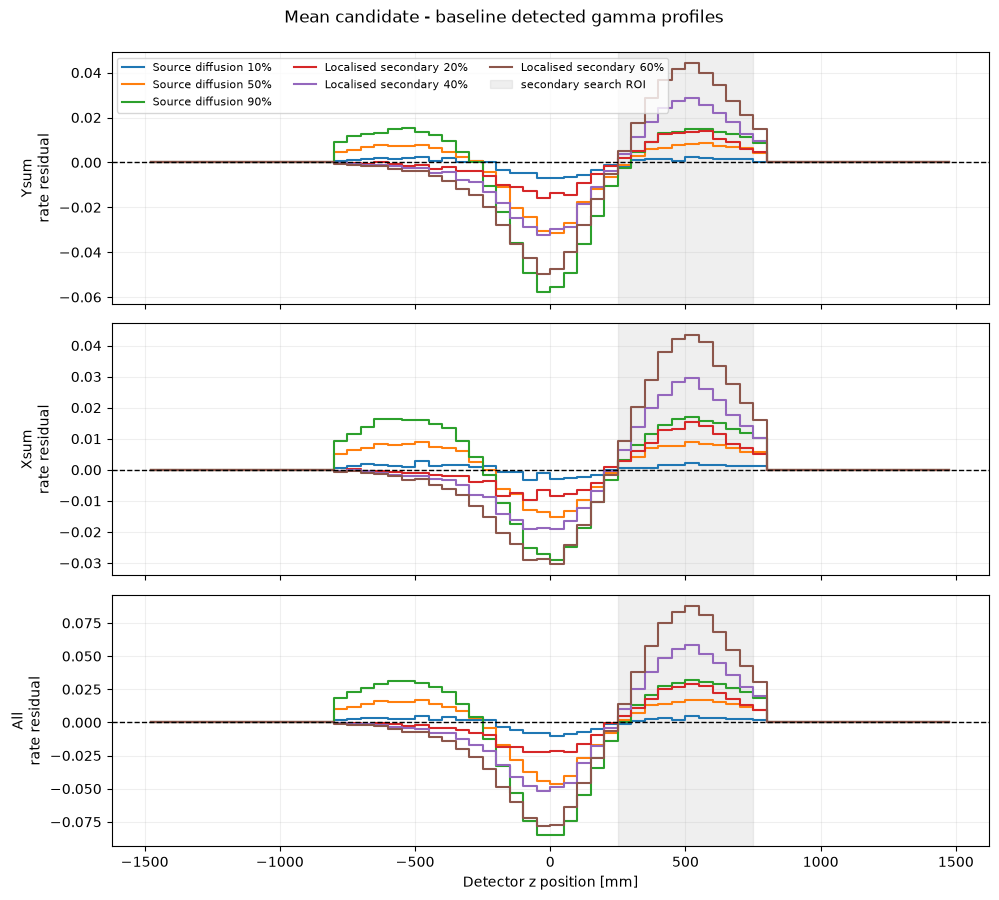

In [59]:
def mean_rate_profile(case_key, view_name):
    profiles = []
    for rep in cases[case_key]:
        profiles.append(hist_counts(rep, panel_sets[view_name]) / rep['n_events'])
    return np.vstack(profiles).mean(axis=0)

views_to_plot = ['Ysum', 'Xsum', 'All']
fig, axes = plt.subplots(len(views_to_plot), 1, figsize=(10, 9), sharex=True)
for ax, view_name in zip(axes, views_to_plot):
    for case_key in [key for key in case_order if key != 'baseline' and key in cases]:
        residual = mean_rate_profile(case_key, view_name) - baseline_profiles[view_name]
        ax.step(z_centers, residual, where='mid', label=case_labels[case_key])
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvspan(secondary_search_z_roi_mm[0], secondary_search_z_roi_mm[1], color='grey', alpha=0.12, label='secondary search ROI' if view_name == views_to_plot[0] else None)
    ax.set_ylabel(f'{view_name}\nrate residual')
    ax.grid(alpha=0.2)
axes[-1].set_xlabel('Detector z position [mm]')
axes[0].legend(fontsize=8, ncols=3)
fig.suptitle('Mean candidate - baseline detected gamma profiles', y=0.995)
plt.tight_layout()
save_figure(fig, 'mean_residual_profiles_for_inference')
plt.show()


## Apply the fitted models to all currently loaded cases

This table is the notebook's compact output: each repetition gets an estimated diffusion fraction where the diffusion model is applicable, signal-amount proxies, a secondary-source probability, and hotspot positions.


In [60]:
X_all_diff = features_df[shape_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_all_sec = features_df[secondary_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

sec_model = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', C=0.5, max_iter=2000))
sec_model.fit(X_sec, y_sec)

final_predictions = features_df[[
    'case', 'rep', 'label', 'diffusion_fraction_true', 'secondary_present_true',
    'secondary_fraction_true', 'secondary_z_mm_true', 'detected_rate_all_per_event',
    'All_central_rate_per_event', 'All_z_q80_width_mm', 'All_positive_residual_peak_z_mm',
    'Xsum_positive_residual_centroid_z_mm', 'Ysum_positive_residual_centroid_z_mm'
]].copy()
final_predictions['diffusion_fraction_estimated_percent'] = np.clip(diff_model.predict(X_all_diff), 0, 100)
final_predictions.loc[~final_predictions['case'].isin(diffusion_training_cases), 'diffusion_fraction_estimated_percent'] = np.nan
final_predictions['relative_total_signal_vs_baseline'] = final_predictions['detected_rate_all_per_event'] / baseline_total_rate
final_predictions['relative_central_signal_vs_baseline'] = final_predictions['All_central_rate_per_event'] / baseline_central_rate
final_predictions['baseline_equivalent_activity_uCi'] = final_predictions['relative_total_signal_vs_baseline'] * reference_activity_uCi
final_predictions['secondary_probability'] = sec_model.predict_proba(X_all_sec)[:, 1]
final_predictions['secondary_present_estimated'] = final_predictions['secondary_probability'] >= 0.5

summary_predictions = final_predictions.groupby('case', sort=False).agg(
    label=('label', 'first'),
    diffusion_true=('diffusion_fraction_true', 'first'),
    diffusion_estimate_mean=('diffusion_fraction_estimated_percent', 'mean'),
    diffusion_estimate_sd=('diffusion_fraction_estimated_percent', 'std'),
    relative_total_signal_mean=('relative_total_signal_vs_baseline', 'mean'),
    relative_total_signal_sd=('relative_total_signal_vs_baseline', 'std'),
    relative_central_signal_mean=('relative_central_signal_vs_baseline', 'mean'),
    relative_central_signal_sd=('relative_central_signal_vs_baseline', 'std'),
    secondary_probability_mean=('secondary_probability', 'mean'),
    secondary_probability_sd=('secondary_probability', 'std'),
    secondary_call_fraction=('secondary_present_estimated', 'mean'),
    hotspot_z_peak_mean=('All_positive_residual_peak_z_mm', 'mean'),
    hotspot_z_peak_sd=('All_positive_residual_peak_z_mm', 'std'),
    xpanel_hotspot_centroid_z_mean=('Xsum_positive_residual_centroid_z_mm', 'mean'),
    ypanel_hotspot_centroid_z_mean=('Ysum_positive_residual_centroid_z_mm', 'mean'),
).reset_index()

final_predictions.to_csv(metrics_output_dir / 'final_signal_inference_by_repetition.csv', index=False)
summary_predictions.to_csv(metrics_output_dir / 'final_signal_inference_summary.csv', index=False)

display(summary_predictions)
print(f"Saved outputs in: {metrics_output_dir}")
print(f"Saved figures in: {figure_output_dir}")


,case,label,diffusion_true,diffusion_estimate_mean,diffusion_estimate_sd,relative_total_signal_mean,relative_total_signal_sd,relative_central_signal_mean,relative_central_signal_sd,secondary_probability_mean,secondary_probability_sd,secondary_call_fraction,hotspot_z_peak_mean,hotspot_z_peak_sd,xpanel_hotspot_centroid_z_mean,ypanel_hotspot_centroid_z_mean
0,baseline,No diffusion baseline,0.0,0.391171,0.720230,1.000000,0.004181,1.000000,0.010493,0.008698,2.377564e-03,0.0,-50.0,187.453698,5.466916,-9.514147
1,diff10,Source diffusion 10%,10.0,10.756577,0.947347,0.999198,0.005528,0.939823,0.008126,0.004727,2.557958e-03,0.0,-160.0,383.731677,-13.412413,-26.706052
2,diff50,Source diffusion 50%,50.0,49.231295,0.573510,1.002040,0.008588,0.721314,0.012491,0.004124,2.728353e-03,0.0,-5.0,532.395008,-4.394501,5.177849
3,diff90,Source diffusion 90%,90.0,89.890565,1.044369,0.992048,0.002784,0.467649,0.008682,0.002408,2.412884e-03,0.0,100.0,582.260919,-6.065806,-1.869772
4,loc20,Localised secondary 20%,NaN,NaN,NaN,1.009003,0.008306,0.846326,0.011410,0.985258,2.803686e-03,1.0,510.0,47.434165,516.322773,521.566298
5,loc40,Localised secondary 40%,NaN,NaN,NaN,1.007245,0.006449,0.668767,0.012569,0.999945,1.799465e-05,1.0,515.0,21.081851,524.826512,531.453471
6,loc60,Localised secondary 60%,NaN,NaN,NaN,1.012495,0.005072,0.503615,0.008705,1.000000,3.969387e-08,1.0,530.0,28.382311,528.686021,533.560645


Saved outputs in: outputs/Simulation_output_signal_inference_metrics
Saved figures in: docs/figures/Simulation_output_signal_inference_metrics
